# Heart Disease UCI

**Objetivo:** Realizar todos los pasos dentro del proceso de preprocesamiento de datos sobre el conjunto de datos de Heart Disease UCI.

El conjunto de datos contiene información clínica de 920 pacientes de 4 instituciones (Cleveland, Hungary, Switzerland, VA Long Beach).
Cada fila consiste en un registro de paciente con variables como edad, sexo, tipo de dolor en el pecho, presión arterial, colesterol, entre otros.
La variable objetivo (`num`) indica el diagnóstico de enfermedad cardíaca (0 = sin enfermedad, 1-4 = distintos niveles de severidad).
Este dataset es ideal para practicar análisis exploratorio, limpieza de datos y modelos de clasificación binaria, multiclase y regresión.

## Paso 1. Carga y Primera Exploración de Datos

Comenzaremos importando las librerías necesarias y cargando el conjunto de datos desde un archivo CSV. Después, realizaremos una primera inspección para entender su estructura, dimensiones y un vistazo inicial a los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import plotly.express as px
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

Empezamos importando librerias necesarias y cargando el conjunto de datos desde un archivo CSV. Despúes, realizaremos una primera inspección para entender su estructura, dimensiones y un vistazo inicial a los datos

In [2]:
# Carga del dataset
# Si usas Google Colab, sube el archivo o monta Drive:
# from google.colab import files; files.upload()
df = pd.read_csv('heart_disease_uci.csv')
df.tail(10)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
910,911,51,Female,VA Long Beach,asymptomatic,114.0,258.0,True,lv hypertrophy,96.0,False,1.0,upsloping,NaN,NaN,0
911,912,62,Male,VA Long Beach,asymptomatic,160.0,254.0,True,st-t abnormality,108.0,True,3.0,flat,NaN,NaN,4
912,913,53,Male,VA Long Beach,asymptomatic,144.0,300.0,True,st-t abnormality,128.0,True,1.5,flat,NaN,NaN,3
913,914,62,Male,VA Long Beach,asymptomatic,158.0,170.0,False,st-t abnormality,138.0,True,0.0,NaN,NaN,NaN,1
914,915,46,Male,VA Long Beach,asymptomatic,134.0,310.0,False,normal,126.0,False,0.0,NaN,NaN,normal,2
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


Para obtener una visión rápida del conjunto de datos, utilizaremos `dataframe.head()`, `dataframe.shape` para conocer el número de filas y columnas, y `dataframe.info()` para identificar los nombres de las columnas, el recuento de valores no nulos y el tipo de dato de cada columna.

In [3]:
df.shape

(920, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


## Paso 2. Limpieza y Preprocesamiento Básico de Datos

En este paso, abordaremos la limpieza inicial de los datos, que incluye la identificación y el manejo de valores faltantes, la corrección de tipos de datos incorrectos y la eliminación de registros inconsistentes.

In [5]:
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


### 2.1. Corrección de Tipos de Datos

Identificamos columnas con tipos de dato incorrectos:
- `fbs` (azúcar en sangre en ayunas) y `exang` (angina inducida por ejercicio) son booleanas pero se leen como `object`.
- `ca` (número de vasos principales coloreados) es flotante pero debería ser entero.
- `id` es un identificador y no aporta valor predictivo.

### 2.2. Manejo de Datos Faltantes

Para identificar los datos faltantes en el conjunto de datos, utilizaremos la función `isnull().sum()` para contar los valores nulos por columna.

In [6]:
print(df.isnull().sum())

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


Observamos que las columnas `ca`, `thal` y `slope` presentan un porcentaje alto de valores nulos. La columna `ca` tiene más del 66% de nulos y `thal` más del 52%, lo que las hace problemáticas para el análisis directo. La columna `id` es solo un identificador y no aporta valor predictivo, por lo tanto se eliminará.

**Paso 6. Identificar datos atípicos:**
Para identificar datos atípicos utilizamos un gráfico de box plot para graficar una de las variables:

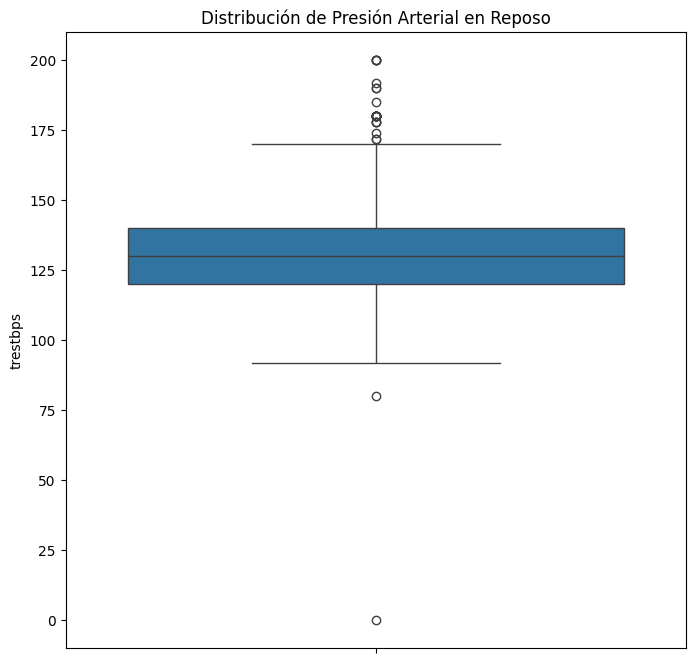

In [7]:
fig = plt.figure(figsize=(8,8))
sns.boxplot(y=df['trestbps'])
plt.title('Distribución de Presión Arterial en Reposo')
plt.show()

Observamos que la presión arterial en reposo (`trestbps`) presenta algunos valores atípicos altos.
➡️ También se pueden analizar los datos utilizando alguna variable categórica, por ejemplo, si tiene o no enfermedad cardíaca y vincularlo a una variable numérica:

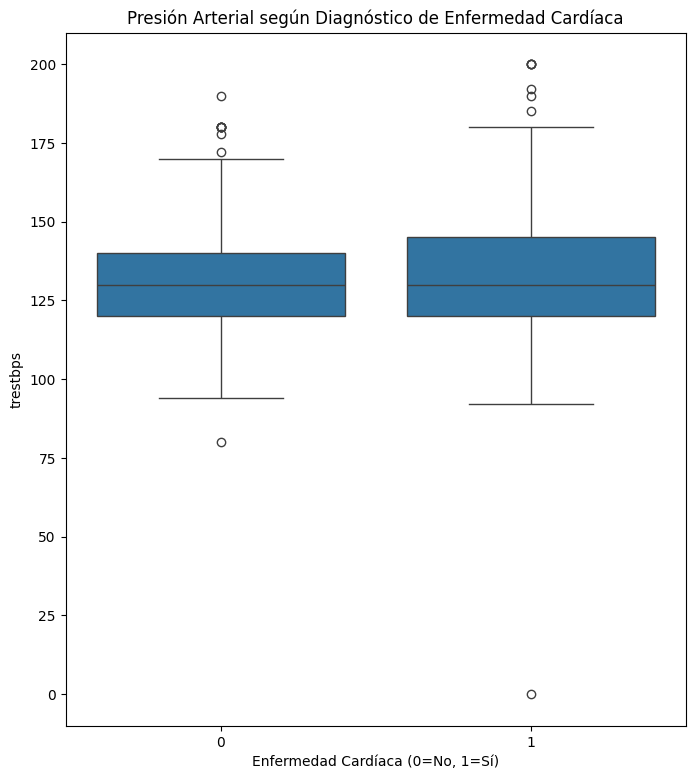

In [8]:
# Crear variable binaria para visualización
df['heart_disease'] = (df['num'] > 0).astype(int)
fig = plt.figure(figsize=(8,9))
sns.boxplot(x='heart_disease', y='trestbps', data=df)
plt.title('Presión Arterial según Diagnóstico de Enfermedad Cardíaca')
plt.xlabel('Enfermedad Cardíaca (0=No, 1=Sí)')
plt.show()

**Paso 7. Calcular las estadísticas:**
`dataframe.describe` para visualizar las estadísticas del conjunto de datos. Por defecto, la función describe trabaja con columnas numéricas.

In [9]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,heart_disease
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


Ahora visualizamos la variable categórica agregandole include=['object'] podemos observar solo las columnas que son categoricas (de tipo object)

In [10]:
df.describe(include=['object'])

,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


**Paso 8. Análisis de tendencia central, posición y dispersión:** 🎯

➡️ `age`: edad del paciente en años.

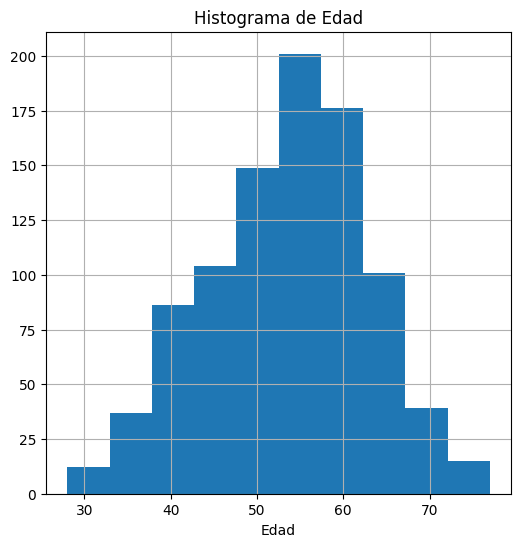

In [11]:
df['age'].hist(figsize=(6,6))
plt.xlabel('Edad')
plt.title('Histograma de Edad')
plt.show()

Este gráfico muestra un ligero sesgo positivo entre las edad aproximadamente 68 - 77 años

In [12]:
mean = df['age'].mean()
median = df['age'].median()
mode = df['age'].mode()
skew = df['age'].skew()
kurt = df['age'].kurt()

print('La media es:', mean)
print('La mediana es:', median)
print('La moda es:', mode.values)
print('El sesgo es:', skew)
print('La kurtosis es:', kurt)

La media es: 53.51086956521739
La mediana es: 54.0
La moda es: [54]
El sesgo es: -0.195993861608106
La kurtosis es: -0.3829298182845311


➡️ `oldpeak`: depresión del segmento ST inducida por el ejercicio relativa al reposo.

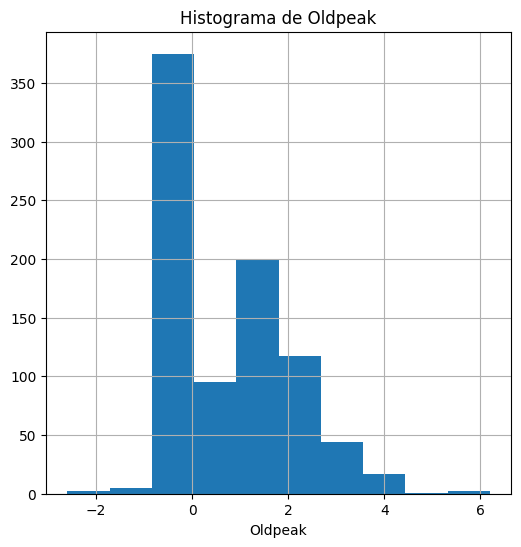

In [13]:
df['oldpeak'].hist(figsize=(6,6))
plt.xlabel('Oldpeak')
plt.title('Histograma de Oldpeak')
plt.show()

In [14]:
mean = df['oldpeak'].mean()
median = df['oldpeak'].median()
mode = df['oldpeak'].mode()
skew = df['oldpeak'].skew()
kurt = df['oldpeak'].kurt()

print('La media es:', mean)
print('La mediana es:', median)
print('La moda es:', mode.values)
print('El sesgo es:', skew)
print('La kurtosis es:', kurt)

La media es: 0.8787878787878788
La mediana es: 0.5
La moda es: [0.]
El sesgo es: 1.0414266146339854
La kurtosis es: 1.1270692393005994


**Paso 9. Contando datos duplicados:**

In [15]:
df.duplicated().sum()

np.int64(0)

**Paso 10. Exploración y visualización de los datos:**

Utilizando técnicas de visualización se puede comenzar a comprender el contexto alrededor de los datos.

**10.1. Análisis de variables numéricas:**

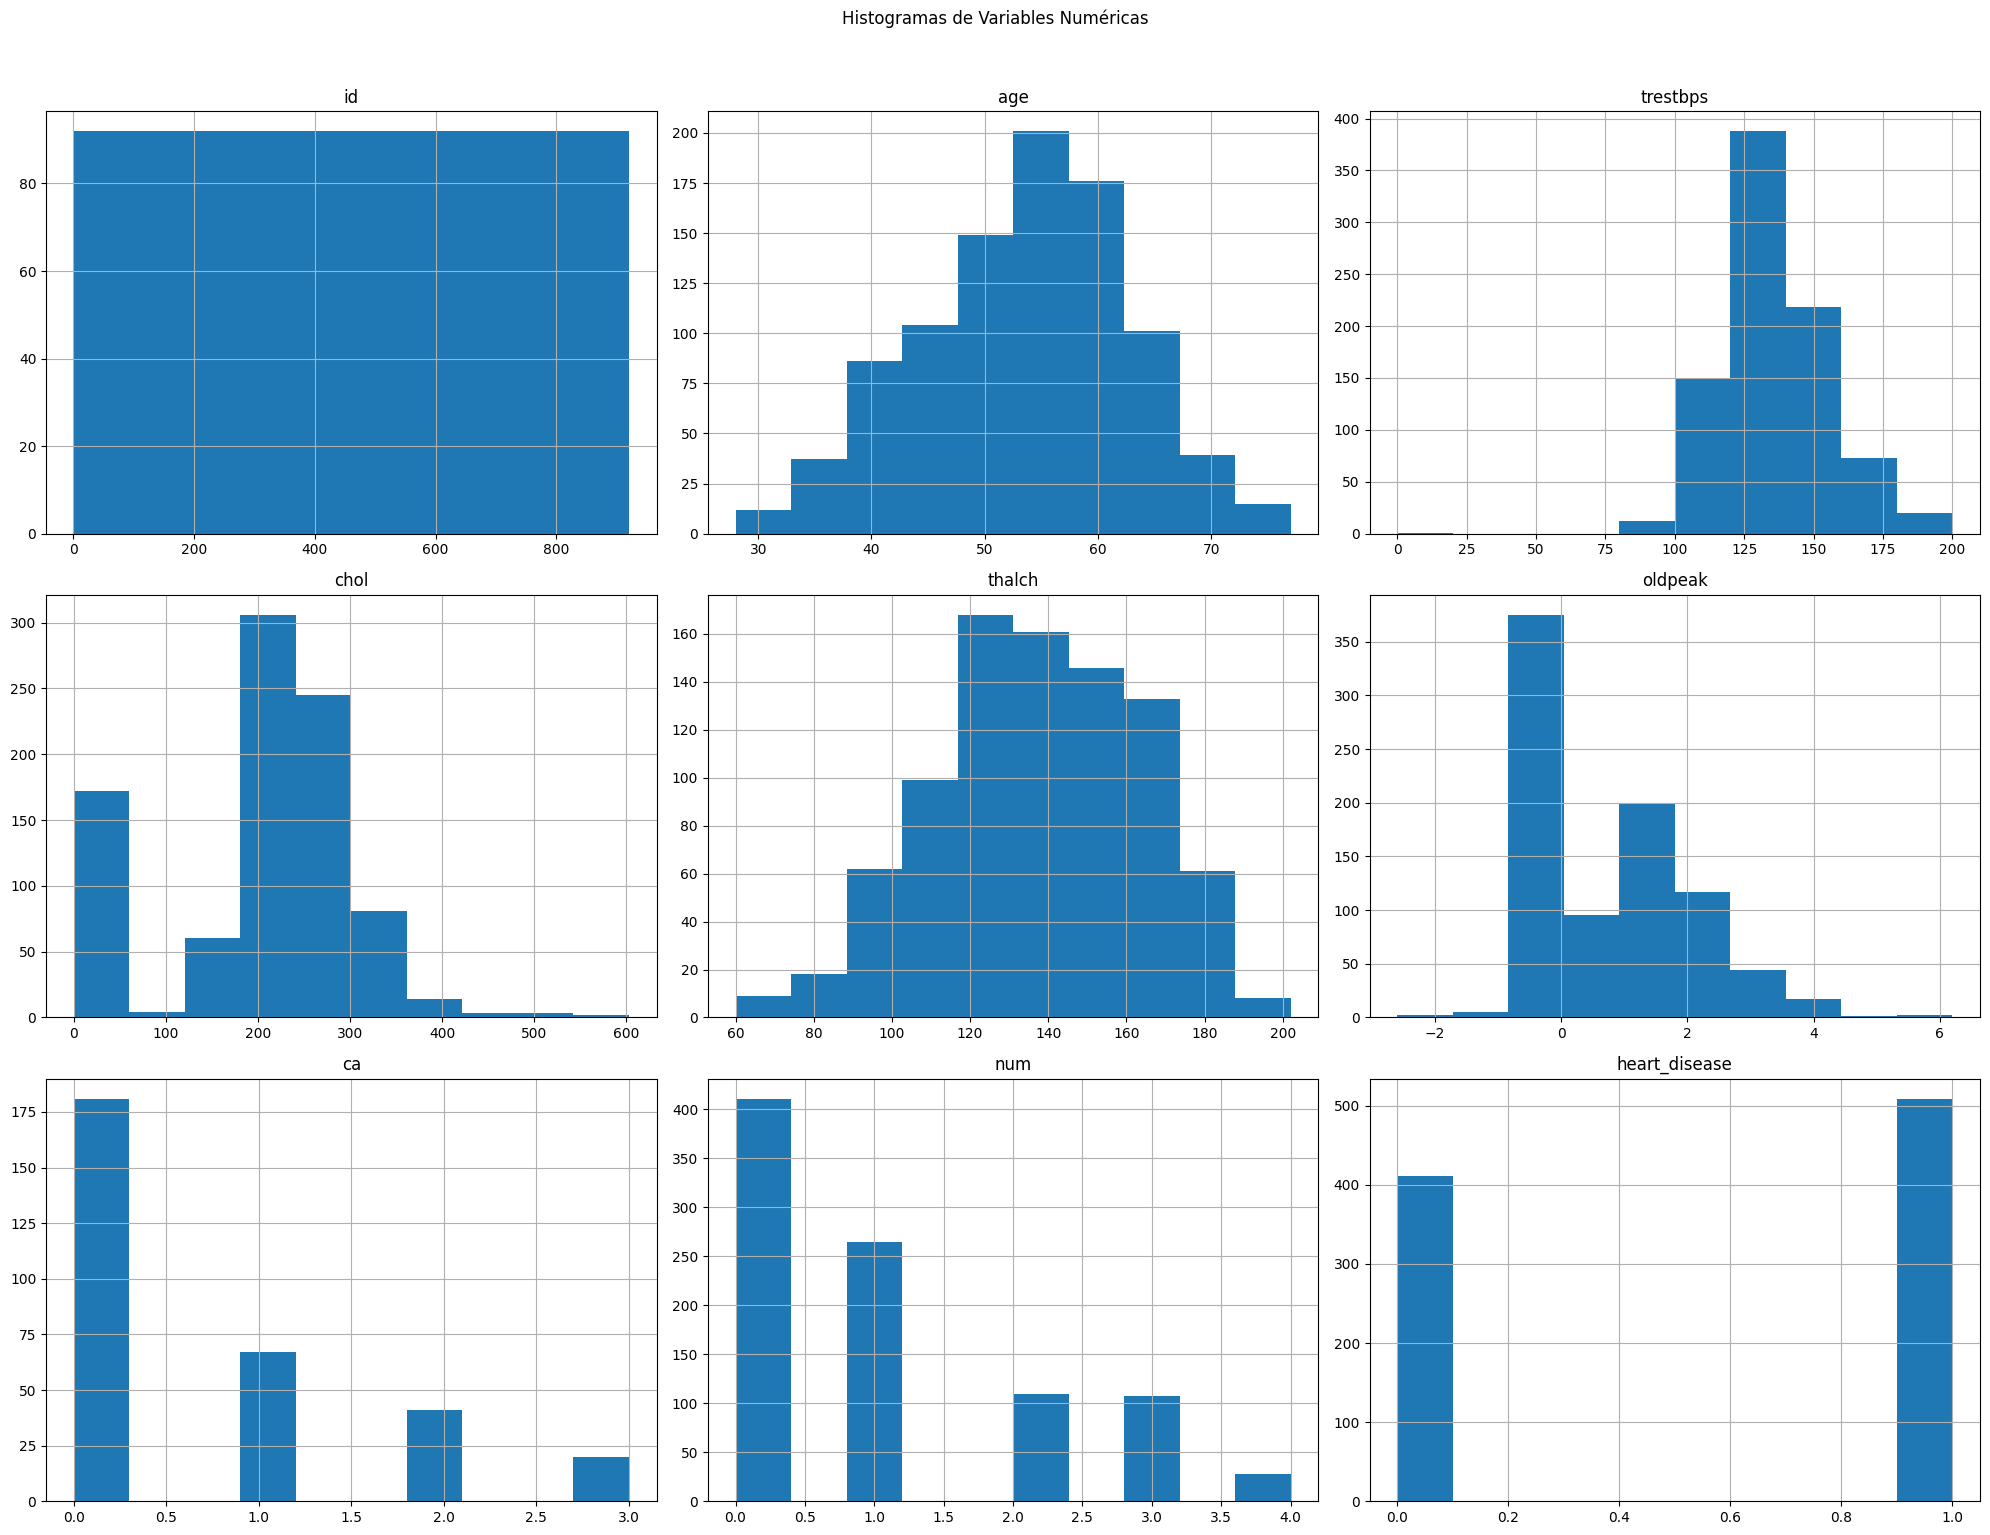

In [16]:
df.hist(figsize=(20,15))
plt.suptitle('Histogramas de Variables Numéricas', y=1.02)
plt.tight_layout()
plt.show()

➡️ Histograma de la variable `age` que muestra la distribución de edades de los pacientes:

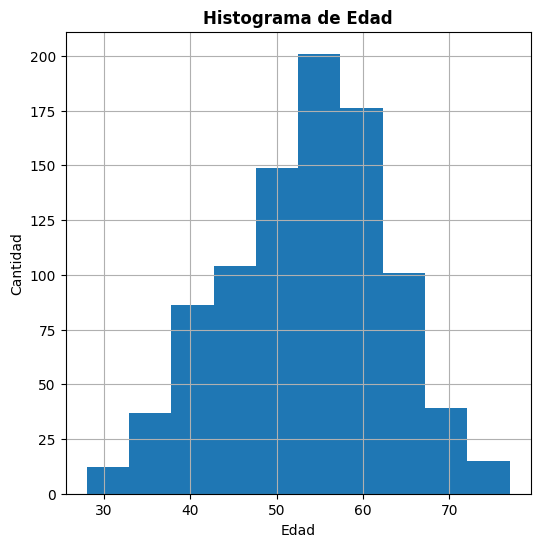

In [17]:
df['age'].hist(figsize=(6,6))
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.title('Histograma de Edad', fontweight='bold')
plt.show()

➡️ En este histograma se aprecia la distribución de la variable `thalch` (frecuencia cardíaca máxima alcanzada):

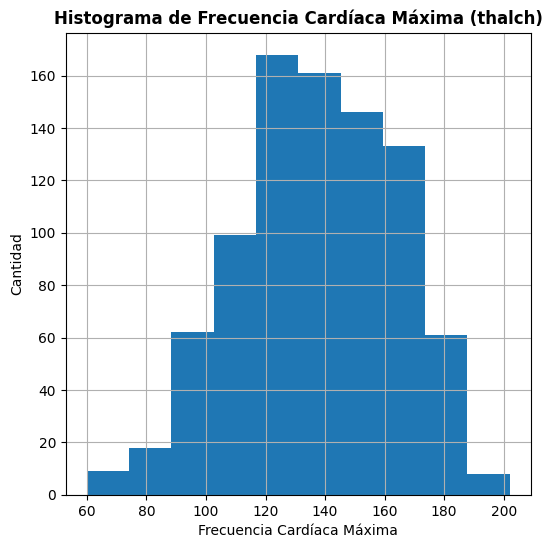

In [18]:
df['thalch'].hist(figsize=(6,6))
plt.xlabel('Frecuencia Cardíaca Máxima')
plt.ylabel('Cantidad')
plt.title('Histograma de Frecuencia Cardíaca Máxima (thalch)', fontweight='bold')
plt.show()

➡️ Para visualizar la relación entre dos variables numéricas se utiliza un gráfico de líneas. Este combina la edad y la frecuencia cardíaca máxima:

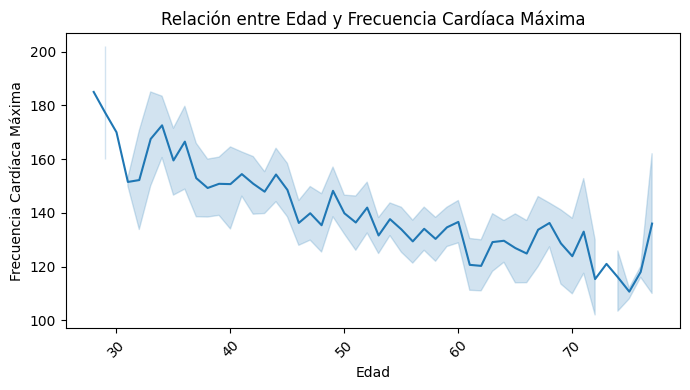

In [19]:
fig = plt.figure(figsize=(7,4), dpi=100)
plt.xticks(rotation=45, fontsize=10)
sns.lineplot(data=df, x='age', y='thalch')
plt.title('Relación entre Edad y Frecuencia Cardíaca Máxima')
plt.xlabel('Edad')
plt.ylabel('Frecuencia Cardíaca Máxima')
plt.tight_layout()
plt.show()

**10.2. Análisis de variables categóricas:**

In [20]:
df_cat = df.select_dtypes(include=['object'])
df_cat.head()

,sex,dataset,cp,fbs,restecg,exang,slope,thal
0,Male,Cleveland,typical angina,True,lv hypertrophy,False,downsloping,fixed defect
1,Male,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,normal
2,Male,Cleveland,asymptomatic,False,lv hypertrophy,True,flat,reversable defect
3,Male,Cleveland,non-anginal,False,normal,False,downsloping,normal
4,Female,Cleveland,atypical angina,False,lv hypertrophy,False,upsloping,normal


In [21]:
for col in df_cat.columns:
    print(f'{col}: \n{df_cat[col].unique()}\n')

sex: 
['Male' 'Female']

dataset: 
['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

cp: 
['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs: 
[True False nan]

restecg: 
['lv hypertrophy' 'normal' 'st-t abnormality' nan]

exang: 
[False True nan]

slope: 
['downsloping' 'flat' 'upsloping' nan]

thal: 
['fixed defect' 'normal' 'reversable defect' nan]



Ahora utilizando gráficos se observa la distribución del diagnóstico principal hy el Nivel de Enfermedad (0=Sano, 1-4=Severidad)

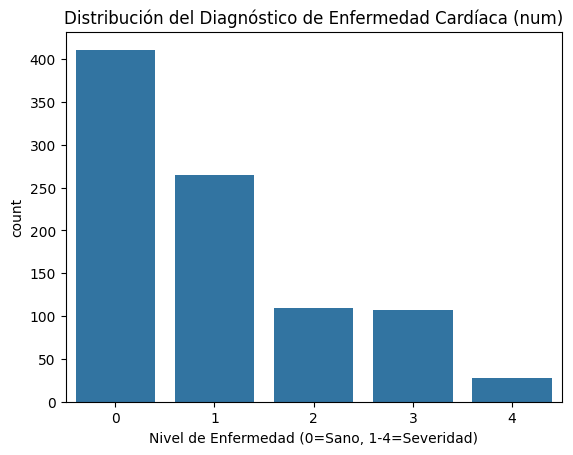

In [22]:
# Distribución del diagnóstico principal
sns.countplot(data=df, x='num')
plt.title('Distribución del Diagnóstico de Enfermedad Cardíaca (num)')
plt.xlabel('Nivel de Enfermedad (0=Sano, 1-4=Severidad)')
plt.show()

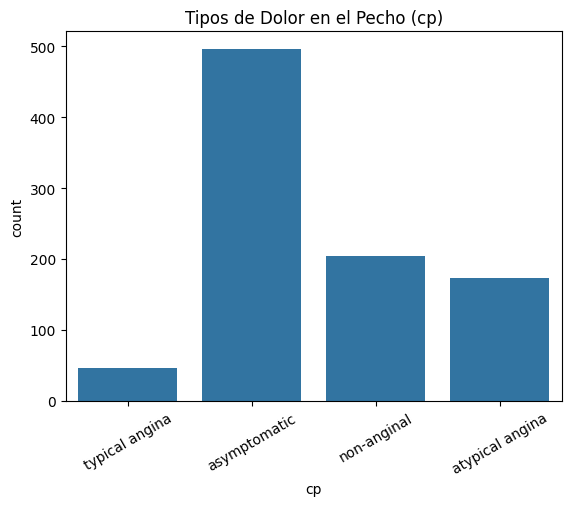

In [23]:
# Distribución por tipo de dolor en el pecho
sns.countplot(data=df, x='cp')
plt.xticks(rotation=30)
plt.title('Tipos de Dolor en el Pecho (cp)')
plt.show()

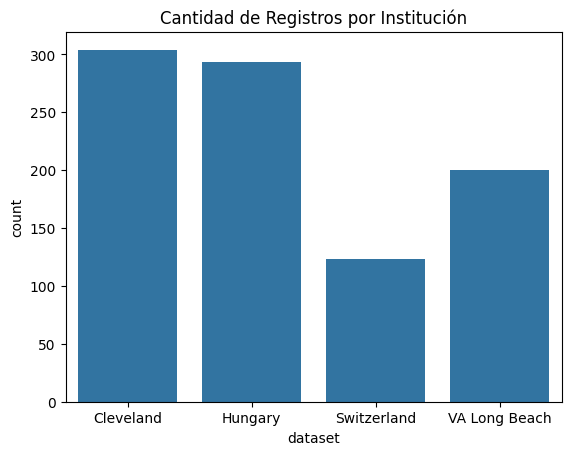

In [24]:
# Distribución por origen del dataset
sns.countplot(data=df, x='dataset')
plt.title('Cantidad de Registros por Institución')
plt.show()

➡️ Análisis de la distribución por institución y sexo de los pacientes con enfermedad cardíaca:

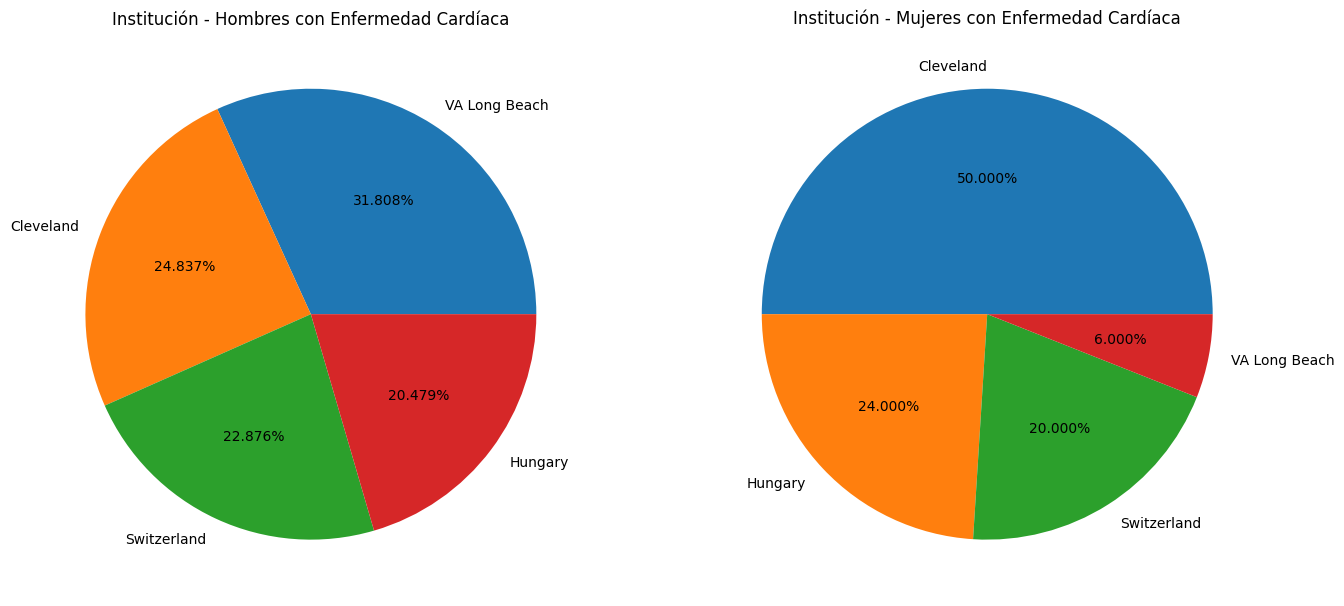

In [25]:
male_hd = pd.DataFrame(df.loc[(df['sex'] == 'Male') & (df['heart_disease'] == 1)])
female_hd = pd.DataFrame(df.loc[(df['sex'] == 'Female') & (df['heart_disease'] == 1)])

fig = plt.figure(figsize=(16, 9))

ax = fig.add_subplot(121)
male_pie = pd.DataFrame(male_hd['dataset'].value_counts())
ax.set_title('Institución - Hombres con Enfermedad Cardíaca', fontsize=12)
ax.pie(x=male_pie['count'], labels=male_pie.index, autopct='%.3f%%')

ax = fig.add_subplot(122)
female_pie = pd.DataFrame(female_hd['dataset'].value_counts())
ax.set_title('Institución - Mujeres con Enfermedad Cardíaca', fontsize=12)
ax.pie(x=female_pie['count'], labels=female_pie.index, autopct='%.3f%%')
plt.show()

**Paso 11. Combinando variables:**

➡️ ¿Qué sexo tiene el mayor número de diagnósticos de enfermedad cardíaca?

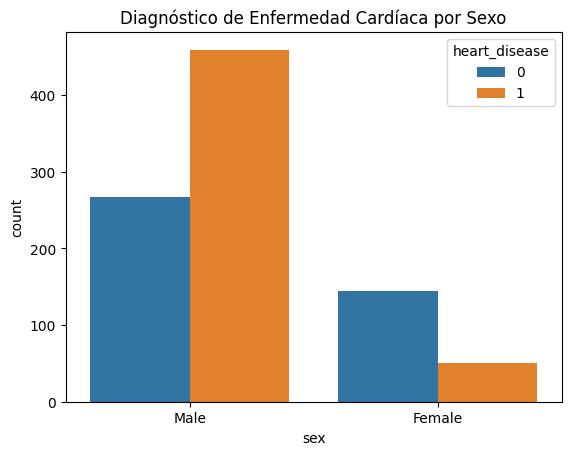

In [26]:
sns.countplot(data=df, x='sex', hue='heart_disease')
plt.title('Diagnóstico de Enfermedad Cardíaca por Sexo')
plt.show()

In [27]:
#¿Cuáles son las instituciones con menor catidad de pacientes de enfermedad cardíaca?
instituciones_mas_visitas = df[df['num'] == 0]['dataset'].value_counts().reset_index()
instituciones_mas_visitas.columns = ['dataset', 'No of patients']
instituciones_mas_visitas

,dataset,No of patients
0,Hungary,187
1,Cleveland,165
2,VA Long Beach,51
3,Switzerland,8


Mapa para visualizar la cantidad de pacientes por cada institución

In [28]:
basemap = folium.Map()
guests_map = px.choropleth(
    instituciones_mas_visitas,
    locations = instituciones_mas_visitas['dataset'],
    color_continuous_scale="portland",
    color = instituciones_mas_visitas['No of patients'],
    hover_name = instituciones_mas_visitas['dataset']
)

guests_map.show()

➡️ ¿Cuáles son las instituciones con más registros y de qué tipo?

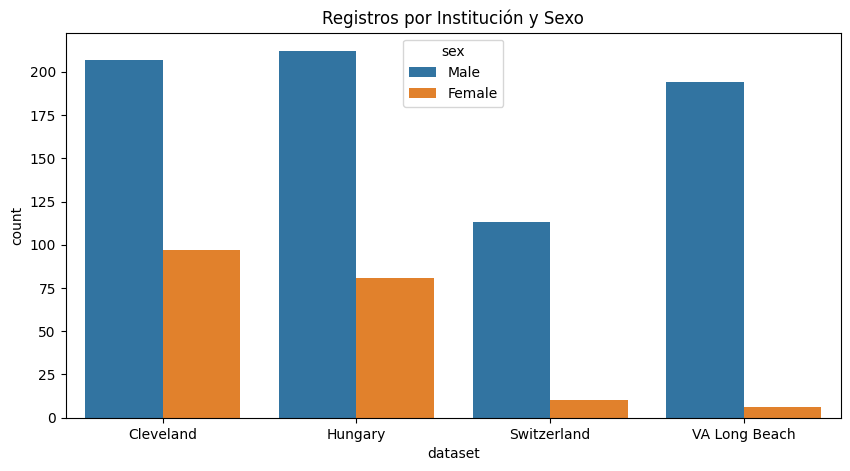

In [29]:
counts = df['dataset'].value_counts()
plt.subplots(figsize=(10,5))
sns.countplot(x='dataset', hue='sex', data=df)
plt.title('Registros por Institución y Sexo')
plt.show()

➡️ ¿Existe alguna relación entre la edad y el diagnóstico de enfermedad cardíaca?

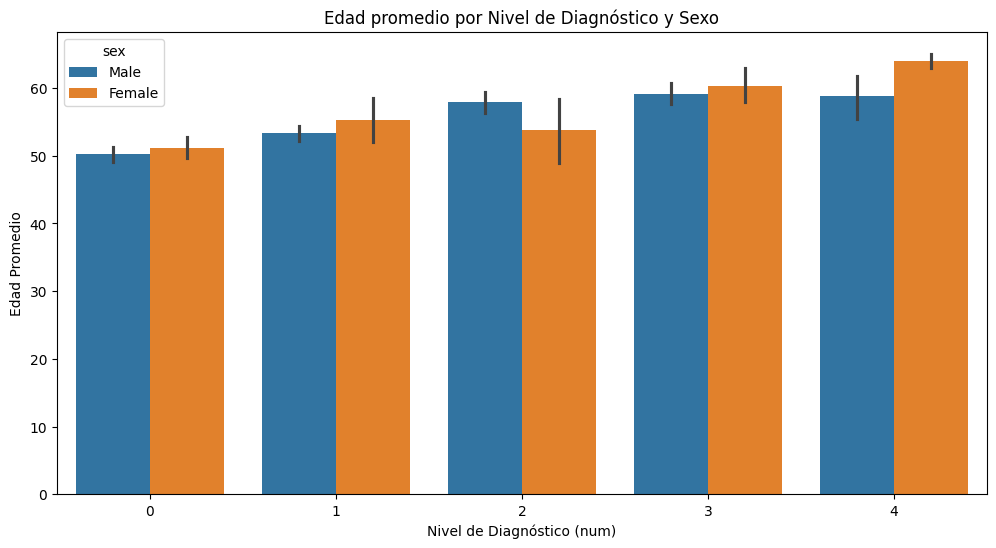

In [30]:
plt.figure(figsize=(12,6))
sns.barplot(x='num', y='age', hue='sex', data=df)
plt.title('Edad promedio por Nivel de Diagnóstico y Sexo')
plt.xlabel('Nivel de Diagnóstico (num)')
plt.ylabel('Edad Promedio')
plt.show()

➡️ Distribuyen las edades de los pacientes

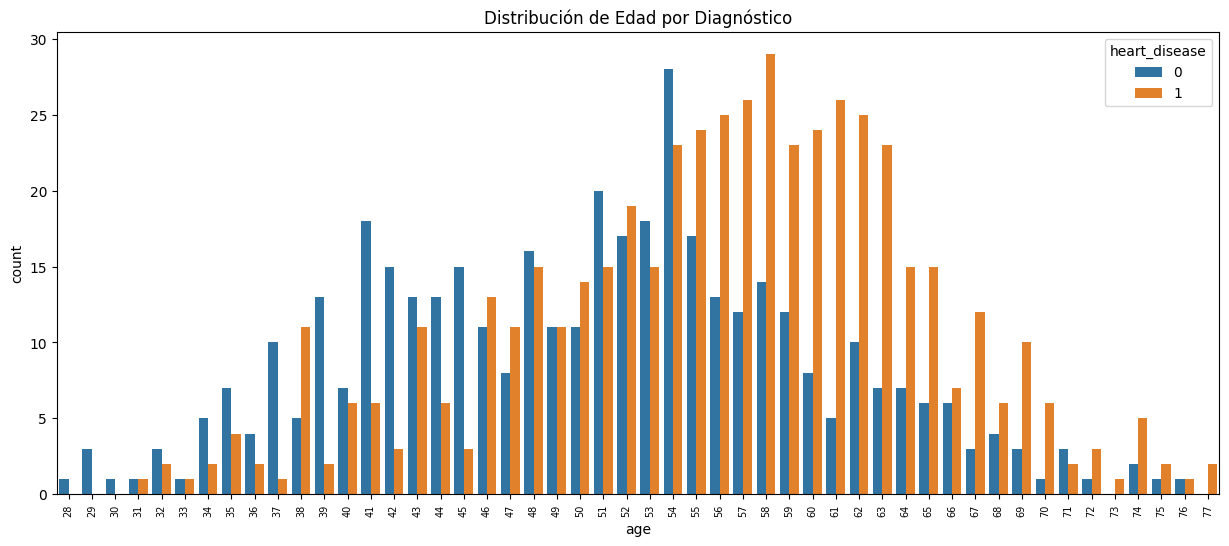

In [31]:
plt.figure(figsize=(15,6))
sns.countplot(data=df, x='age', hue='heart_disease')
plt.xticks(rotation=90, fontsize=7)
plt.title('Distribución de Edad por Diagnóstico')
plt.show()

➡️ ¿Qué tipo de dolor en el pecho presentan más frecuentemente los pacientes con enfermedad?

- **typical angina**: angina típica
- **atypical angina**: angina atípica
- **non-anginal**: dolor no anginoso
- **asymptomatic**: asintomático

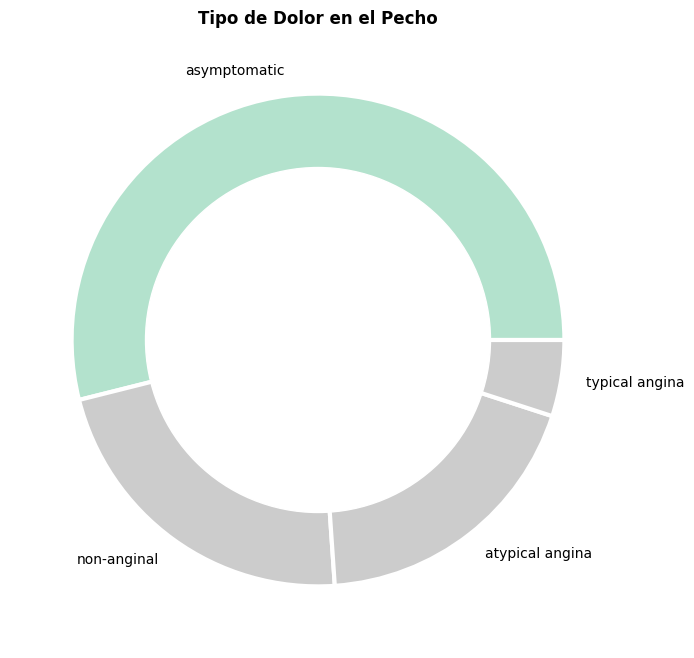

In [32]:
cp_labels = df['cp'].value_counts().index.tolist()
size = df['cp'].value_counts()
plt.figure(figsize=(8,8))
cmap = plt.get_cmap('Pastel2')
colors = cmap(np.arange(len(cp_labels))*1.0)
my_circle = plt.Circle((0,0), 0.7, color='white')
plt.pie(size, labels=cp_labels, colors=colors, wedgeprops={'linewidth':3,'edgecolor':'white'})
p = plt.gcf()
p.gca().add_artist(my_circle)
plt.title('Tipo de Dolor en el Pecho', weight='bold')
plt.show()

➡️ Análisis de la relación entre `restecg` (resultados del electrocardiograma en reposo) y el diagnóstico:

Se puede analizar la cantidad de pacientes según la edad sin enfermedades cardiacas,

Cantidad de pacientes en la institución de Cleveland

In [33]:
pacientes_cleveland = df[df['dataset'] == 'Cleveland'][df['num'] == 0]['age'].value_counts().reset_index()
pacientes_cleveland.columns = ['Edad', 'N° Pacientes']
pacientes_cleveland

,Edad,N° Pacientes
0,54,10
1,52,9
2,41,9
3,51,9
4,44,8
5,58,7
6,42,7
7,57,7
8,64,6
9,53,6


Se visualiza los resultados de la Institución Cleveland

<Axes: xlabel='N° Pacientes', ylabel='Edad'>

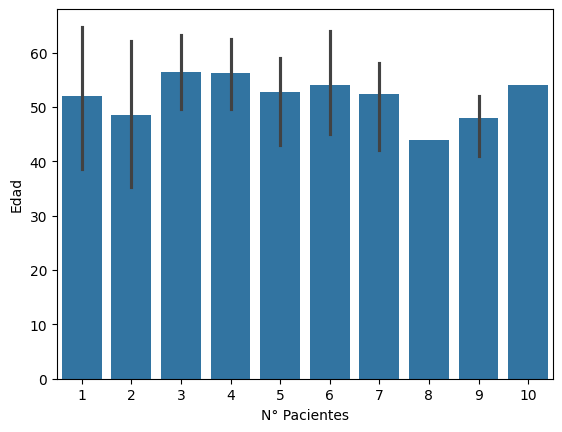

In [34]:
sns.barplot(x = "N° Pacientes", y = "Edad", data = pacientes_cleveland)

Ahora utlizamos la Institución Hungary
---



In [35]:
pacientes_hungary = df[df['dataset'] == 'Hungary'][df['num'] == 0]['age'].value_counts().reset_index()
pacientes_hungary.columns = ['Edad', 'N° Pacientes']
pacientes_hungary

,Edad,N° Pacientes
0,54,16
1,48,11
2,39,10
3,55,10
4,53,9
5,43,8
6,49,8
7,52,8
8,50,7
9,51,7


Se visualizarón los resultados de Hungary

<Axes: xlabel='N° Pacientes', ylabel='Edad'>

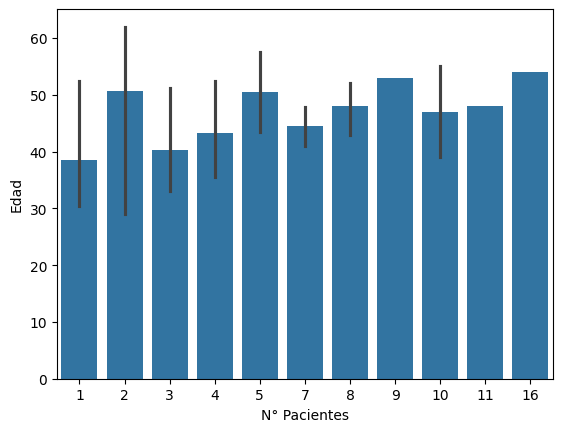

In [36]:
sns.barplot(x = "N° Pacientes", y = "Edad", data = pacientes_hungary)

Cual es la Institución con mas pacientes y el sexo

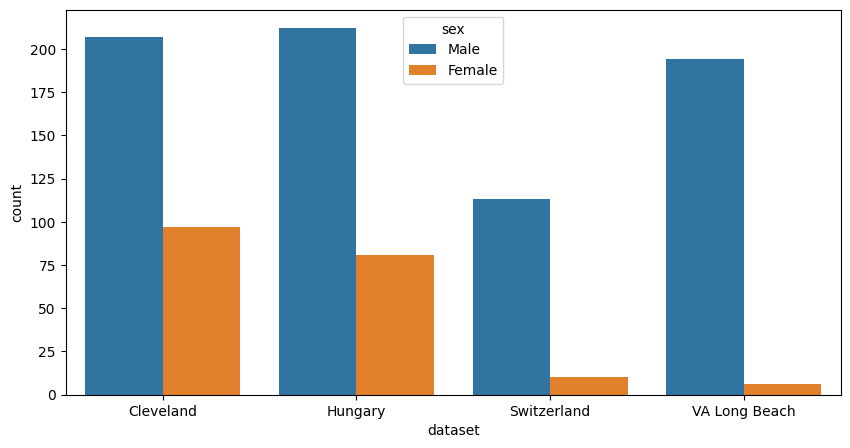

In [37]:
counts = df['dataset'].value_counts()
plt.subplots(figsize = (10, 5))
sns.countplot(x= 'dataset', hue='sex', data=df) # Changed 'hue' to 'sex' and removed the incorrect filter
plt.show()

In [38]:
counts = df['dataset'].value_counts()
counts

,count
dataset,
Cleveland,304
Hungary,293
VA Long Beach,200
Switzerland,123


Analsizamos la influencia de ECG en Reposo en enfermedades cardiacas por Institución

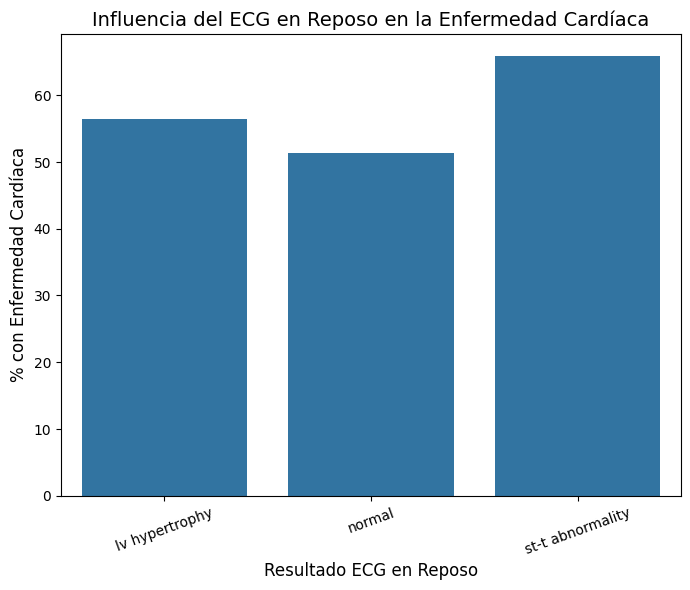

In [39]:
restecg_cancel = df.groupby('restecg')['heart_disease'].describe()
plt.figure(figsize=(8,6))
sns.barplot(x=restecg_cancel.index, y=restecg_cancel['mean']*100)
plt.title('Influencia del ECG en Reposo en la Enfermedad Cardíaca', fontsize=14)
plt.xlabel('Resultado ECG en Reposo', fontsize=12)
plt.ylabel('% con Enfermedad Cardíaca', fontsize=12)
plt.xticks(rotation=20)
plt.show()

### 2.3. Tratamiento de Valores Faltantes

Para las columnas con muchos nulos como `ca` (66%) y `thal` (52%), imputaremos con la moda por ser variables categóricas/discretas. Para variables numéricas como `trestbps`, `chol`, `thalch` y `oldpeak`, imputaremos con la mediana dado el sesgo de su distribución.

In [40]:
print(df.isnull().sum())

id                 0
age                0
sex                0
dataset            0
cp                 0
trestbps          59
chol              30
fbs               90
restecg            2
thalch            55
exang             55
oldpeak           62
slope            309
ca               611
thal             486
num                0
heart_disease      0
dtype: int64


In [41]:
df[['trestbps','chol','fbs','thalch','exang','oldpeak','slope','ca','thal']].describe(include='all')

,trestbps,chol,fbs,thalch,exang,oldpeak,slope,ca,thal
count,861.000000,890.000000,830,865.000000,865,858.000000,611,309.000000,434
unique,NaN,NaN,2,NaN,2,NaN,3,NaN,3
top,NaN,NaN,False,NaN,False,NaN,flat,NaN,normal
freq,NaN,NaN,692,NaN,528,NaN,345,NaN,196
mean,132.132404,199.130337,NaN,137.545665,NaN,0.878788,NaN,0.676375,NaN
std,19.066070,110.780810,NaN,25.926276,NaN,1.091226,NaN,0.935653,NaN
min,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000,NaN
25%,120.000000,175.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000,NaN
50%,130.000000,223.000000,NaN,140.000000,NaN,0.500000,NaN,0.000000,NaN
75%,140.000000,268.000000,NaN,157.000000,NaN,1.500000,NaN,1.000000,NaN


La columna `id` es solo un identificador que no aporta valor predictivo. Por lo tanto, se eliminará.

In [42]:
df = df.drop(['id'], axis=1)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            920 non-null    int64  
 1   sex            920 non-null    object 
 2   dataset        920 non-null    object 
 3   cp             920 non-null    object 
 4   trestbps       861 non-null    float64
 5   chol           890 non-null    float64
 6   fbs            830 non-null    object 
 7   restecg        918 non-null    object 
 8   thalch         865 non-null    float64
 9   exang          865 non-null    object 
 10  oldpeak        858 non-null    float64
 11  slope          611 non-null    object 
 12  ca             309 non-null    float64
 13  thal           434 non-null    object 
 14  num            920 non-null    int64  
 15  heart_disease  920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


Para las columnas numéricas (`trestbps`, `chol`, `thalch`, `oldpeak`) imputamos con la **mediana** por su distribución sesgada. Para columnas categóricas (`fbs`, `exang`, `slope`, `ca`, `thal`) imputamos con la **moda** (valor más frecuente).

In [44]:
# Imputar variables numéricas con mediana
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df[col].fillna(df[col].median(), inplace=True)

# Imputar variables categóricas con moda
for col in ['fbs', 'exang', 'restecg', 'slope', 'thal']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Para 'ca' usar mediana (variable discreta numérica)
df['ca'].fillna(df['ca'].median(), inplace=True)

print(df.isnull().sum())

age              0
sex              0
dataset          0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalch           0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
num              0
heart_disease    0
dtype: int64


### 2.4. Ajuste de Tipos de Datos

Una vez tratados los valores faltantes, se corrigen los tipos de datos: `ca` de `float` a `int`, y `fbs`/`exang` a tipo booleano.

In [45]:
df['ca'] = df['ca'].astype('int')
df['fbs'] = df['fbs'].astype('bool')
df['exang'] = df['exang'].astype('bool')
df.dtypes

,0
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,bool
restecg,object
thalch,float64
exang,bool


### 2.5. Manejo de Datos Inconsistentes

Es fundamental identificar registros con información ilógica. Por ejemplo, pacientes con `chol` = 0 o `trestbps` = 0 no son fisiológicamente posibles.

In [46]:
filter_inconsistent = (df['chol'] == 0) | (df['trestbps'] == 0)
print('Registros inconsistentes:', filter_inconsistent.sum())

Registros inconsistentes: 172


In [47]:
# Reemplazar ceros fisiológicamente imposibles con la mediana
df.loc[df['chol'] == 0, 'chol'] = df['chol'].median()
df.loc[df['trestbps'] == 0, 'trestbps'] = df['trestbps'].median()

# Verificación
print('Total registros:', df.shape[0])

Total registros: 920


In [48]:
# Verificar que todas las variables numéricas tengan valores válidos
filter_valid = df['age'] > 0
df_check = df[filter_valid]
print('Registros válidos:', df_check.shape[0])

Registros válidos: 920


**Paso 15. Datos atípicos:**

Se comienza con la detección de outliers visualizando los boxplots de las variables numéricas principales.

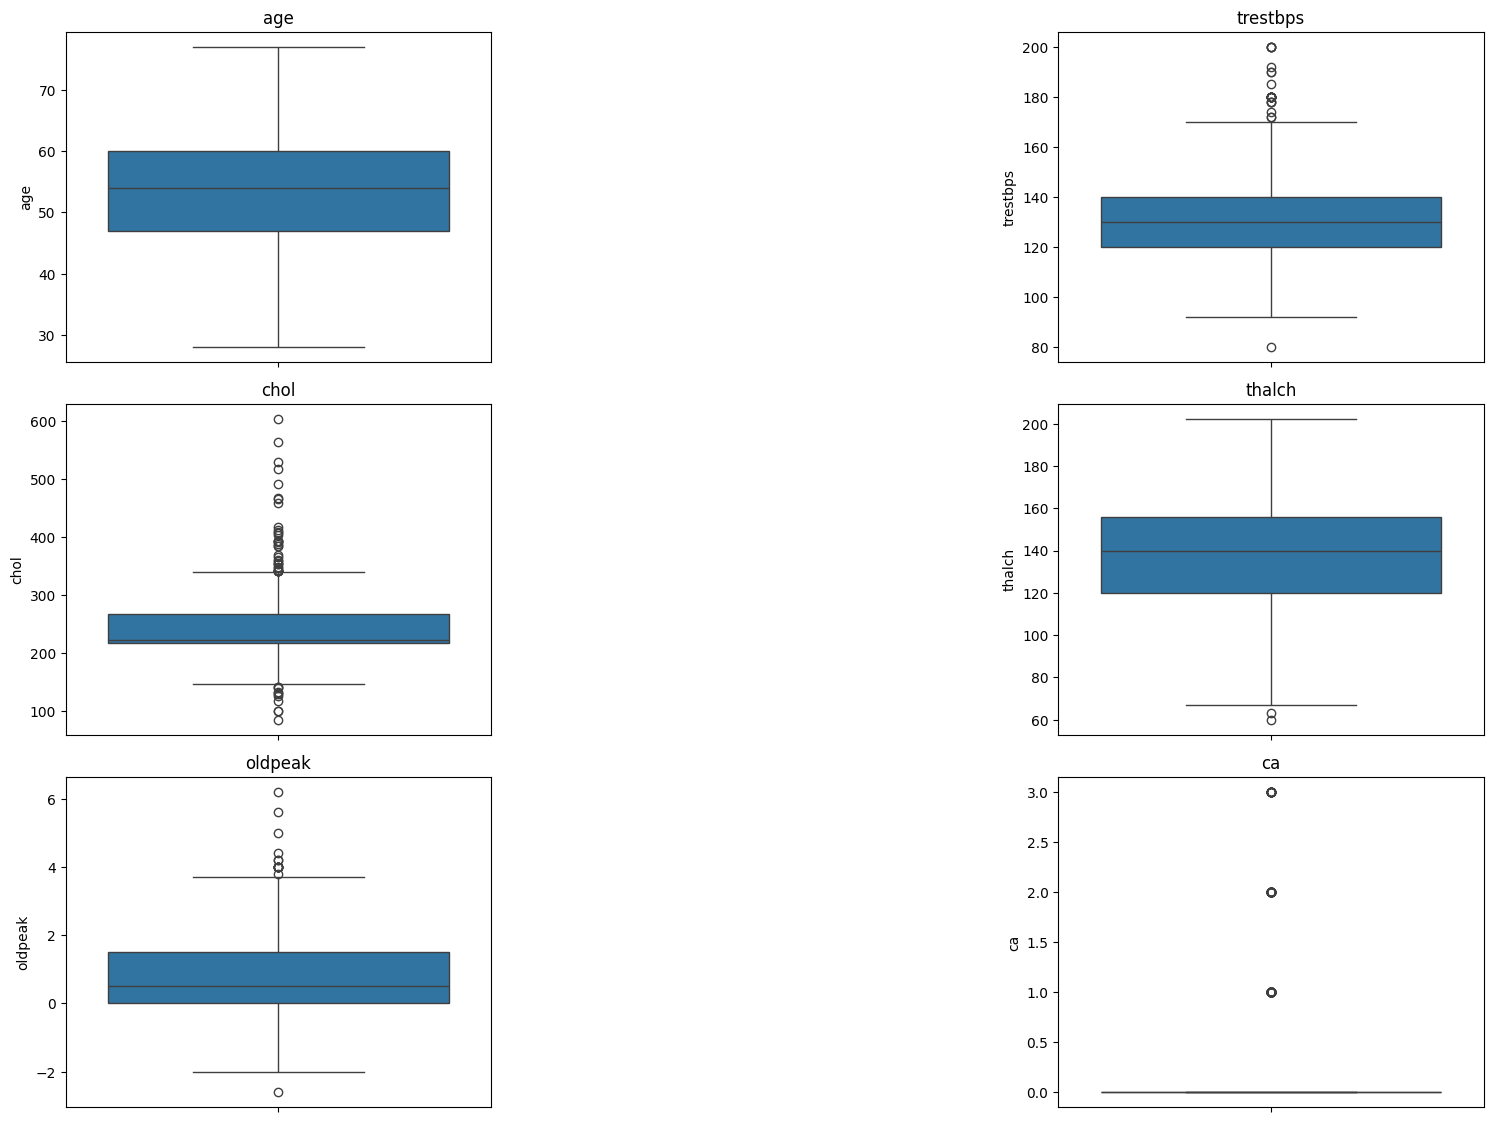

In [49]:
columnas = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
n = 1
plt.figure(figsize=(20,15))
for column in columnas:
    plt.subplot(4, 4, n)
    n += 2
    sns.boxplot(y=df[column])
    plt.title(column)
    plt.tight_layout()

➡️ Se procede a sustituir los valores atípicos por el límite del último cuartil o por la mediana según el caso.

In [50]:
df.loc[df['trestbps'] > 200, 'trestbps'] = 200
df.loc[df['chol'] > 500, 'chol'] = 500
df.loc[df['thalch'] < 60, 'thalch'] = 60
df.loc[df['oldpeak'] > 5, 'oldpeak'] = 5
df.loc[df['oldpeak'] < 0, 'oldpeak'] = 0

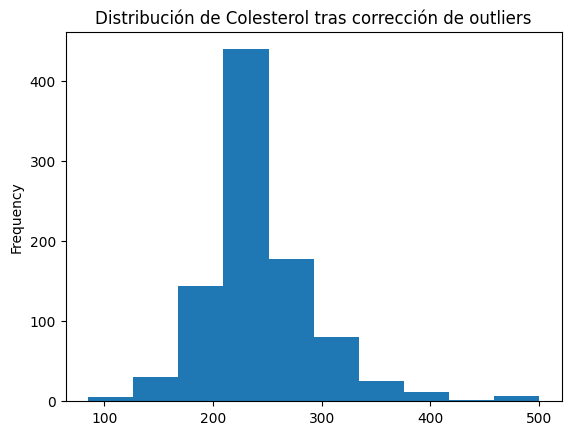

In [51]:
df['chol'].plot(kind='hist')
plt.title('Distribución de Colesterol tras corrección de outliers')
plt.show()

➡️ Se utiliza el algoritmo LOF (Local Outlier Factor) para detectar registros atípicos multivariados:

In [52]:
select_df = df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']]

model = LocalOutlierFactor(n_neighbors=30)
y_pred_lof = model.fit_predict(select_df)
print('Total atípicos detectados por LOF:', (y_pred_lof == -1).sum())

Total atípicos detectados por LOF: 23


In [53]:
outlier_index = (y_pred_lof == -1)
outlier_values = select_df.iloc[outlier_index]
outlier_values.head(10)

,age,trestbps,chol,thalch,oldpeak,ca
48,65,140.0,417.0,157.0,0.8,1
152,67,115.0,500.0,160.0,1.6,0
188,54,192.0,283.0,195.0,0.0,1
306,30,170.0,237.0,170.0,0.0,0
338,39,190.0,241.0,106.0,0.0,0
373,44,150.0,412.0,170.0,0.0,0
375,45,180.0,223.0,180.0,0.0,0
431,52,140.0,100.0,138.0,0.0,0
434,53,113.0,468.0,127.0,0.0,0
473,56,120.0,85.0,140.0,0.0,0


**Paso 16. Datos redundantes:**

Para identificar atributos redundantes se utiliza la matriz de correlación sobre los atributos numéricos.

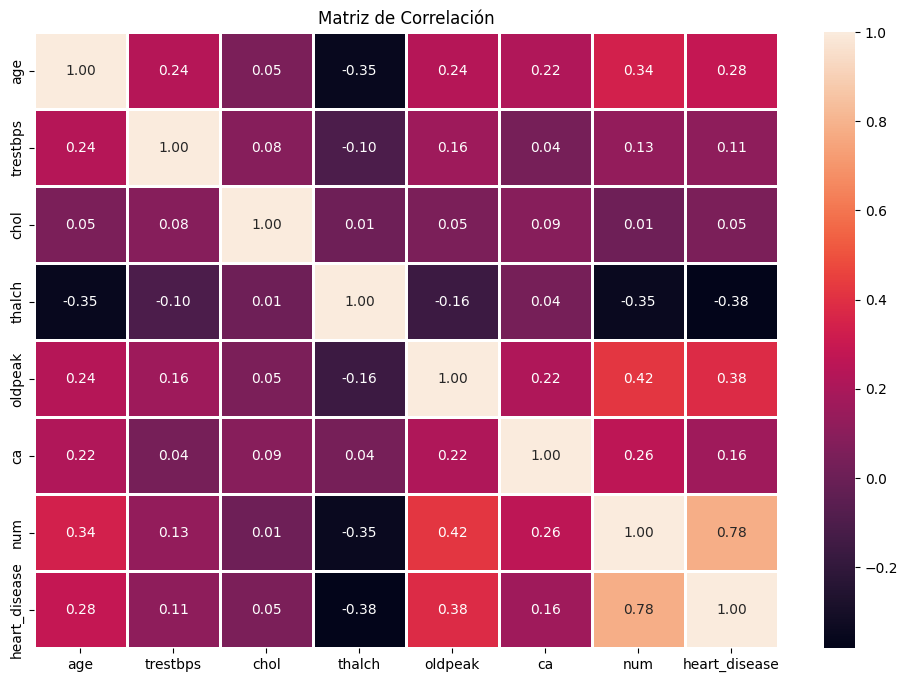

In [54]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, linewidths=1, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

**Paso 17. Datos duplicados:**

In [55]:
df.duplicated().sum()

np.int64(2)

In [56]:
df.loc[df.duplicated(), :]

,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,heart_disease
405,49,Female,Hungary,atypical angina,110.0,223.0,False,normal,160.0,False,0.0,flat,0,normal,0,0
907,58,Male,VA Long Beach,non-anginal,150.0,219.0,False,st-t abnormality,118.0,True,0.0,flat,0,normal,2,1


In [57]:
df_drop = df.drop_duplicates()
df_drop.shape

(918, 16)

**Paso 18. Transformaciones a los datos:**

**18.1. Normalización:**
La normalización es necesaria para poner todas las variables numéricas en la misma escala.

In [58]:
df_normalize = df_drop.copy()
scaler = MinMaxScaler()
cols_to_scale = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df_normalize[cols_to_scale] = scaler.fit_transform(df_drop[cols_to_scale])
df_normalize[cols_to_scale].tail(10)

,age,trestbps,chol,thalch,oldpeak
910,0.469388,0.283333,0.416867,0.253521,0.2
911,0.693878,0.666667,0.407229,0.338028,0.6
912,0.510204,0.533333,0.518072,0.478873,0.3
913,0.693878,0.650000,0.204819,0.549296,0.0
914,0.367347,0.450000,0.542169,0.464789,0.0
915,0.530612,0.391667,0.597590,0.661972,0.0
916,0.693878,0.416667,0.130120,0.563380,0.1
917,0.551020,0.350000,0.332530,0.281690,0.0
918,0.612245,0.416667,0.722892,0.563380,0.1
919,0.693878,0.333333,0.407229,0.232394,0.0


**18.2. Discretización:**

Para realizar un ejemplo de discretización se utiliza la variable `age` (edad del paciente). Primero se visualiza su distribución:

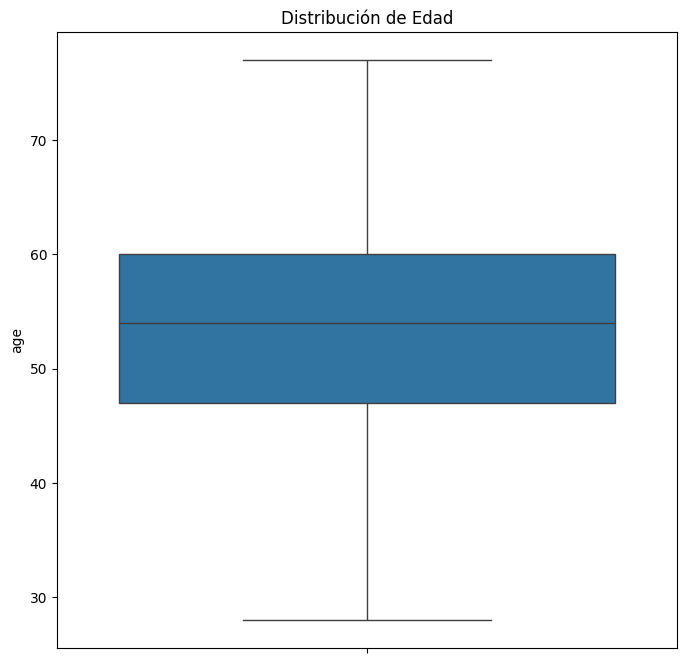

In [59]:
fig = plt.figure(figsize=(8,8))
sns.boxplot(y=df['age'])
plt.title('Distribución de Edad')
plt.show()

In [60]:
grupoEdad = ['Joven', 'Adulto Joven', 'Adulto Medio', 'Adulto Mayor', 'Anciano']
df['age_binned'] = pd.cut(x=df['age'],
                    bins=[0, 35, 45, 55, 65, 100],
                    labels=grupoEdad, include_lowest=True)
df[['age', 'age_binned']].head(10)

,age,age_binned
0,63,Adulto Mayor
1,67,Anciano
2,67,Anciano
3,37,Adulto Joven
4,41,Adulto Joven
5,56,Adulto Mayor
6,62,Adulto Mayor
7,57,Adulto Mayor
8,63,Adulto Mayor
9,53,Adulto Medio


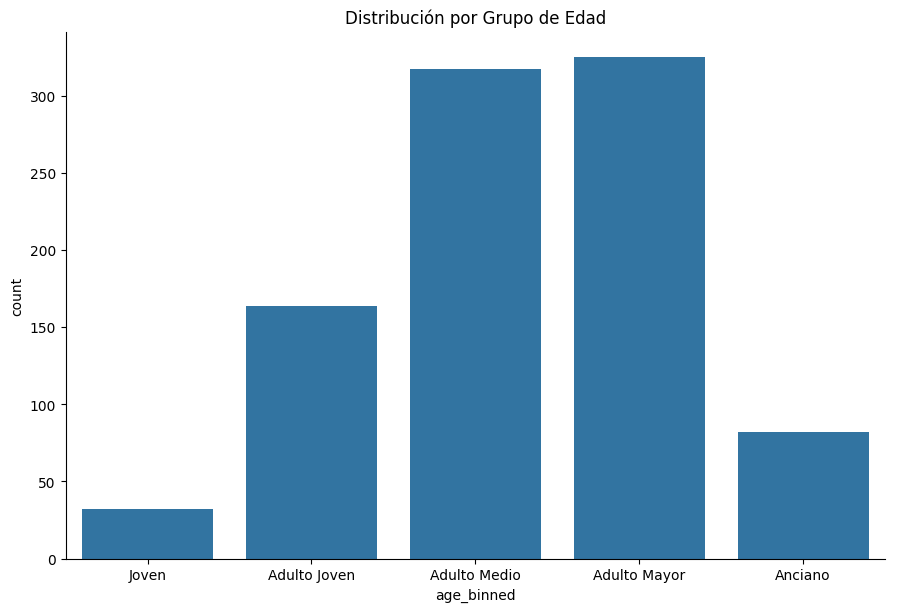

In [61]:
sns.catplot(x='age_binned', kind='count', data=df, height=6, aspect=1.5)
plt.title('Distribución por Grupo de Edad')
plt.show()

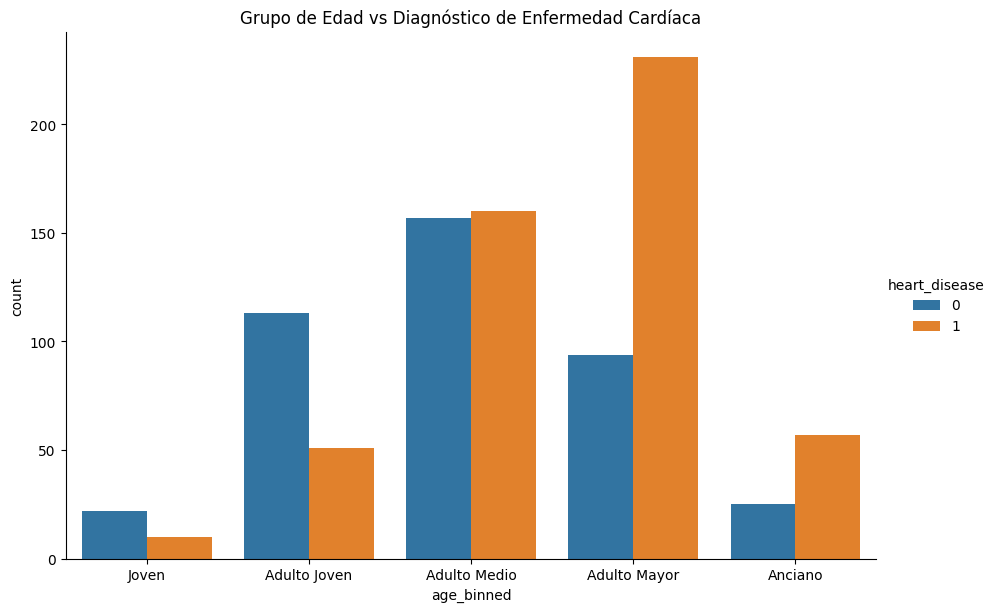

In [62]:
sns.catplot(x='age_binned', hue='heart_disease', kind='count', data=df, height=6, aspect=1.5)
plt.title('Grupo de Edad vs Diagnóstico de Enfermedad Cardíaca')
plt.show()

**Paso 19. Numerización:**

El objetivo de numerizar es convertir a número distintas variables categóricas. Las siguientes variables se pueden numerizar 1 a 1:

In [63]:
df_cat = df_drop.select_dtypes(include=['object', 'bool']).copy()
df_cat['sex'] = df_cat['sex'].map({'Male': 0, 'Female': 1})
df_cat['fbs'] = df_cat['fbs'].astype(int)
df_cat['exang'] = df_cat['exang'].astype(int)
df_cat.head()

,sex,dataset,cp,fbs,restecg,exang,slope,thal
0,0,Cleveland,typical angina,1,lv hypertrophy,0,downsloping,fixed defect
1,0,Cleveland,asymptomatic,0,lv hypertrophy,1,flat,normal
2,0,Cleveland,asymptomatic,0,lv hypertrophy,1,flat,reversable defect
3,0,Cleveland,non-anginal,0,normal,0,downsloping,normal
4,1,Cleveland,atypical angina,0,lv hypertrophy,0,upsloping,normal


➡️ Para las variables nominales sin orden natural (como `cp`, `restecg`, `slope`, `thal`, `dataset`) se crean variables dummy (One-Hot Encoding):

In [64]:
df_cat = pd.get_dummies(df_cat, columns=['cp'])
df_cat = pd.get_dummies(df_cat, columns=['restecg'])
df_cat = pd.get_dummies(df_cat, columns=['slope'])
df_cat = pd.get_dummies(df_cat, columns=['thal'])
df_cat = pd.get_dummies(df_cat, columns=['dataset'])
df_cat.head()

,sex,fbs,exang,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,dataset_Cleveland,dataset_Hungary,dataset_Switzerland,dataset_VA Long Beach
0,0,1,0,False,False,False,True,True,False,False,True,False,False,True,False,False,True,False,False,False
1,0,0,1,True,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False
2,0,0,1,True,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False
3,0,0,0,False,False,True,False,False,True,False,True,False,False,False,True,False,True,False,False,False
4,1,0,0,False,True,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False


**Paso 20. Técnicas de muestreo:**

Si el objetivo fuera predecir la variable `heart_disease` se debería analizar el balance de las clases:

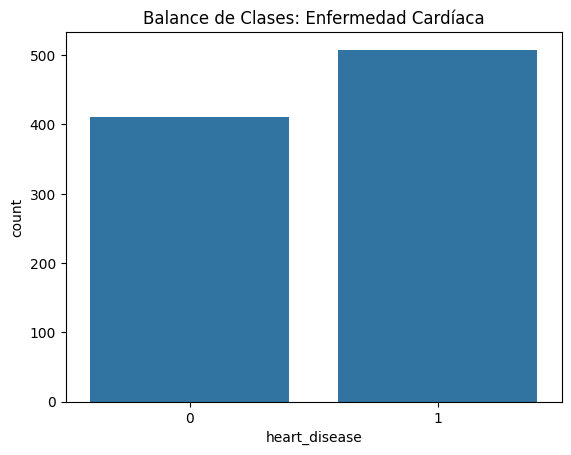

In [65]:
sns.countplot(data=df_drop, x='heart_disease')
plt.title('Balance de Clases: Enfermedad Cardíaca')
plt.show()

➡️ Es evidente que hay más pacientes sin enfermedad que con ella, se aplica submuestreo para balancear las clases:

In [66]:
from sklearn.utils import resample

count_no, count_yes = df_drop['heart_disease'].value_counts()
df_class_no = df_drop[df_drop['heart_disease'] == 0]
df_class_yes = df_drop[df_drop['heart_disease'] == 1]

no_downsampled = resample(df_class_no,
                          replace=False,
                          n_samples=count_yes,
                          random_state=27)
df_balanceado = pd.concat([df_class_yes, no_downsampled])

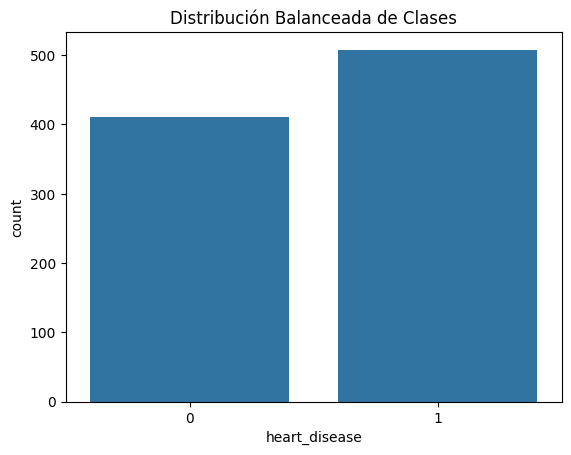

In [67]:
sns.countplot(data=df_balanceado, x='heart_disease')
plt.title('Distribución Balanceada de Clases')
plt.show()

In [68]:
print(df_balanceado['heart_disease'].value_counts())
print(df_balanceado.shape)

heart_disease
1    508
0    410
Name: count, dtype: int64
(918, 16)


### Guardar DataFrames procesados

In [69]:
df.to_csv('df.csv', index=False)
print('df.csv guardado!')
df_drop.to_csv('df_drop.csv', index=False)
print('df_drop.csv guardado!')
df_normalize.to_csv('df_normalize.csv', index=False)
print('df_normalize.csv guardado!')
df_balanceado.to_csv('df_balanceado.csv', index=False)
print('df_balanceado.csv guardado!')

df.csv guardado!
df_drop.csv guardado!
df_normalize.csv guardado!
df_balanceado.csv guardado!


# Observamos los DataFrames df_drop, df_normalize y df_balanceado

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            920 non-null    int64   
 1   sex            920 non-null    object  
 2   dataset        920 non-null    object  
 3   cp             920 non-null    object  
 4   trestbps       920 non-null    float64 
 5   chol           920 non-null    float64 
 6   fbs            920 non-null    bool    
 7   restecg        920 non-null    object  
 8   thalch         920 non-null    float64 
 9   exang          920 non-null    bool    
 10  oldpeak        920 non-null    float64 
 11  slope          920 non-null    object  
 12  ca             920 non-null    int64   
 13  thal           920 non-null    object  
 14  num            920 non-null    int64   
 15  heart_disease  920 non-null    int64   
 16  age_binned     920 non-null    category
dtypes: bool(2), category(1), float64(4)

In [71]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    int64  
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(4), int64(4), object(6)
memory usage: 109.4+ KB


In [72]:
df_normalize.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    float64
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 109.4+ KB


In [73]:
df_balanceado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 30
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    int64  
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(4), int64(4), object(6)
memory usage: 109.4+ KB


# MODELO DE REGRESIÓN: Predicción de la Frecuencia Cardíaca Máxima (`thalch`)

Se predice la frecuencia cardíaca máxima alcanzada por el paciente, que es una variable numérica continua.

In [74]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Selección de variables predictoras y target
X = df_normalize.drop(columns=['thalch', 'heart_disease', 'num', 'age_binned'], errors='ignore')
y = df_normalize['thalch']

# Codificación de variables categóricas
X = pd.get_dummies(X, drop_first=True)

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputación
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Regresión Lineal
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred_linear = reg_model.predict(X_test)
print('Linear Regression:')
print('MAE:', mean_absolute_error(y_test, y_pred_linear))
print('MSE:', mean_squared_error(y_test, y_pred_linear))
print('R²:', r2_score(y_test, y_pred_linear))
print()

# Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
print('Ridge Regression:')
print('MAE:', mean_absolute_error(y_test, y_pred_ridge))
print('MSE:', mean_squared_error(y_test, y_pred_ridge))
print('R²:', r2_score(y_test, y_pred_ridge))
print()

# Lasso
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
print('Lasso Regression:')
print('MAE:', mean_absolute_error(y_test, y_pred_lasso))
print('MSE:', mean_squared_error(y_test, y_pred_lasso))
print('R²:', r2_score(y_test, y_pred_lasso))

Linear Regression:
MAE: 0.11483784983493113
MSE: 0.02098549364920824
R²: 0.35476137864759794

Ridge Regression:
MAE: 0.11492150521820074
MSE: 0.020937614131755905
R²: 0.35623352480476633

Lasso Regression:
MAE: 0.11518007025714569
MSE: 0.020806512413905298
R²: 0.3602644946307275


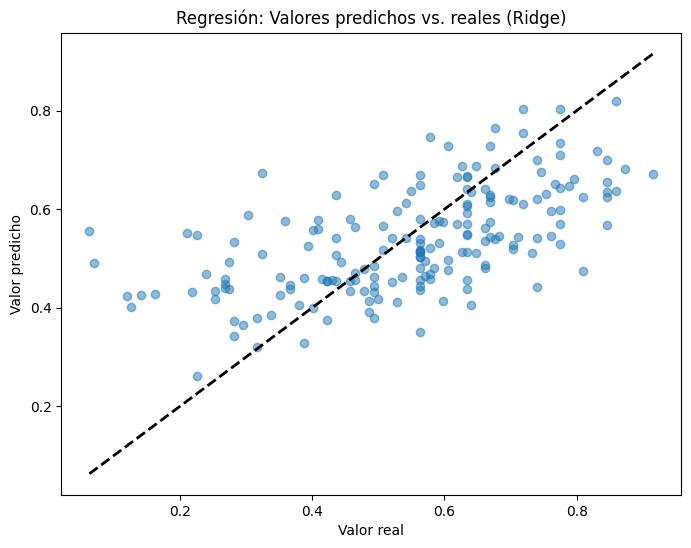

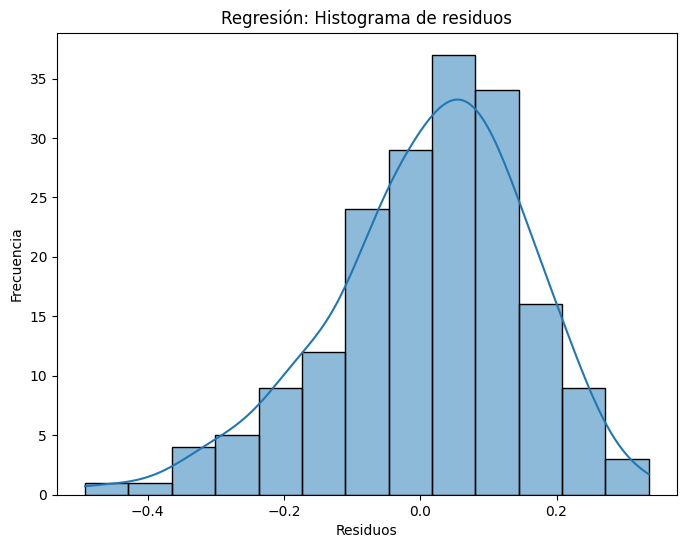

Regresión Ridge:
MSE: 0.020937614131755905
R²: 0.35623352480476633


In [75]:
# Visualización de métricas para el modelo de regresión
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valor real')
plt.ylabel('Valor predicho')
plt.title('Regresión: Valores predichos vs. reales (Ridge)')
plt.show()

residuals = y_test - y_pred_ridge
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.title('Regresión: Histograma de residuos')
plt.show()

print('Regresión Ridge:')
print('MSE:', mean_squared_error(y_test, y_pred_ridge))
print('R²:', r2_score(y_test, y_pred_ridge))

# MODELO DE CLASIFICACIÓN BINARIA: Diagnóstico de Enfermedad Cardíaca

Se predice si el paciente tiene o no enfermedad cardíaca (`heart_disease`). Se utiliza el `df_balanceado`.

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              r2_score, classification_report, confusion_matrix)

X = df_balanceado.drop(columns=['heart_disease', 'num', 'age_binned'], errors='ignore')
y = df_balanceado['heart_disease']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_bin1 = LogisticRegression(random_state=42, max_iter=1500)
clf_bin1.fit(X_train, y_train)
y_pred_logistic = clf_bin1.predict(X_test)

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_logistic))
print('Accuracy:', accuracy_score(y_test, y_pred_logistic))
print('Precision:', precision_score(y_test, y_pred_logistic))
print('Recall:', recall_score(y_test, y_pred_logistic))
print('R2:', r2_score(y_test, y_pred_logistic))
print('Classification Report:')
print(classification_report(y_test, y_pred_logistic))

Confusion Matrix:
[[65 15]
 [11 93]]
Accuracy: 0.8586956521739131
Precision: 0.8611111111111112
Recall: 0.8942307692307693
R2: 0.42499999999999993
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83        80
           1       0.86      0.89      0.88       104

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



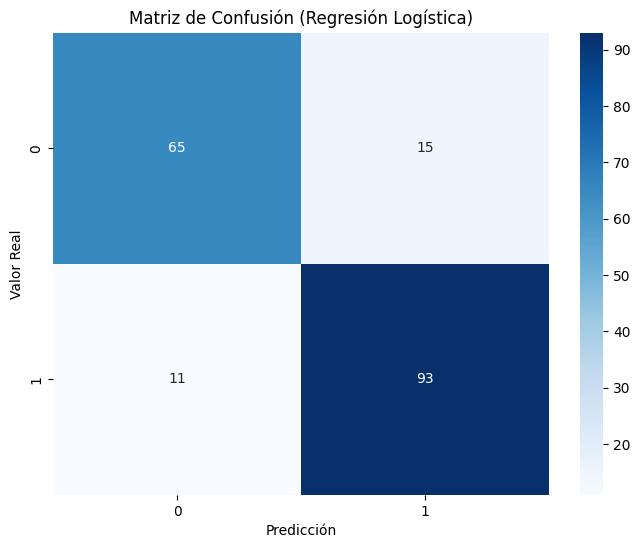

In [77]:
cm = confusion_matrix(y_test, y_pred_logistic)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.show()

# Construimos un Modelo de Árbol de Decisión

Accuracy: 0.7282608695652174
[[61 19]
 [31 73]]
              precision    recall  f1-score   support

           0       0.66      0.76      0.71        80
           1       0.79      0.70      0.74       104

    accuracy                           0.73       184
   macro avg       0.73      0.73      0.73       184
weighted avg       0.74      0.73      0.73       184



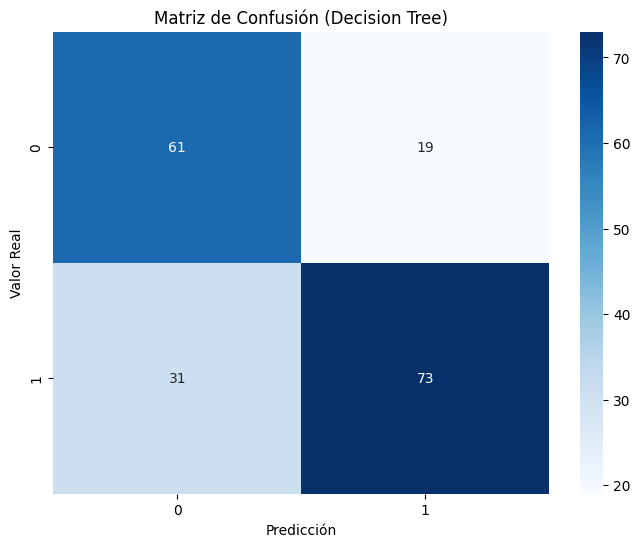

In [78]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

X = df_balanceado.drop(columns=['heart_disease', 'num', 'age_binned'], errors='ignore')
y = df_balanceado['heart_disease']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_tree = DecisionTreeClassifier(max_depth=10, min_samples_split=15, random_state=42, criterion='gini')
clf_tree.fit(X_train, y_train)
y_pred_tree = clf_tree.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Decision Tree)')
plt.show()

**Reglas de texto del árbol:**

Reglas del árbol de decisión:
 |--- exang <= 0.29
|   |--- dataset_Switzerland <= 1.13
|   |   |--- age <= 0.34
|   |   |   |--- thal_normal <= -0.58
|   |   |   |   |--- age <= -0.30
|   |   |   |   |   |--- chol <= -0.02
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- chol >  -0.02
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  -0.30
|   |   |   |   |   |--- ca <= 0.45
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- ca >  0.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- thal_normal >  -0.58
|   |   |   |   |--- dataset_VA Long Beach <= 0.69
|   |   |   |   |   |--- chol <= 4.45
|   |   |   |   |   |   |--- oldpeak <= 1.03
|   |   |   |   |   |   |   |--- cp_atypical angina <= 0.77
|   |   |   |   |   |   |   |   |--- cp_non-anginal <= 0.69
|   |   |   |   |   |   |   |   |   |--- sex_Male <= -0.68
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   |--- sex_Male >  -0.68
|   |   |   |   

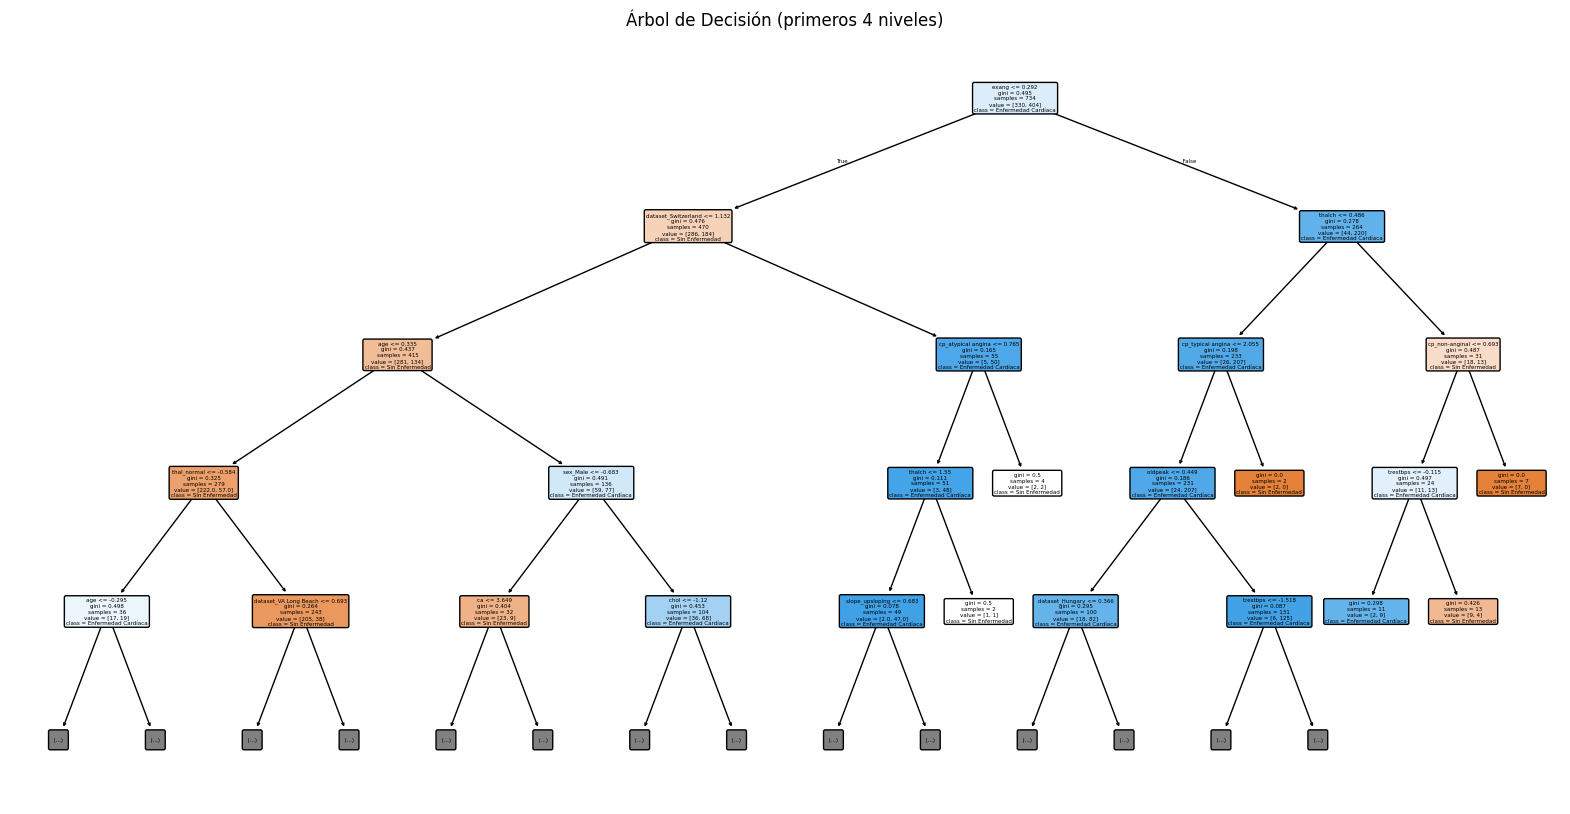

In [79]:
tree_rules = export_text(clf_tree, feature_names=list(X.columns))
print('Reglas del árbol de decisión:\n', tree_rules[:3000], '...')

plt.figure(figsize=(20,10))
plot_tree(clf_tree, feature_names=list(X.columns), filled=True, rounded=True,
          class_names=['Sin Enfermedad', 'Enfermedad Cardíaca'], max_depth=4)
plt.title('Árbol de Decisión (primeros 4 niveles)')
plt.show()

# Modelo Random Forest

Accuracy: 0.8369565217391305
[[63 17]
 [13 91]]
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        80
           1       0.84      0.88      0.86       104

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



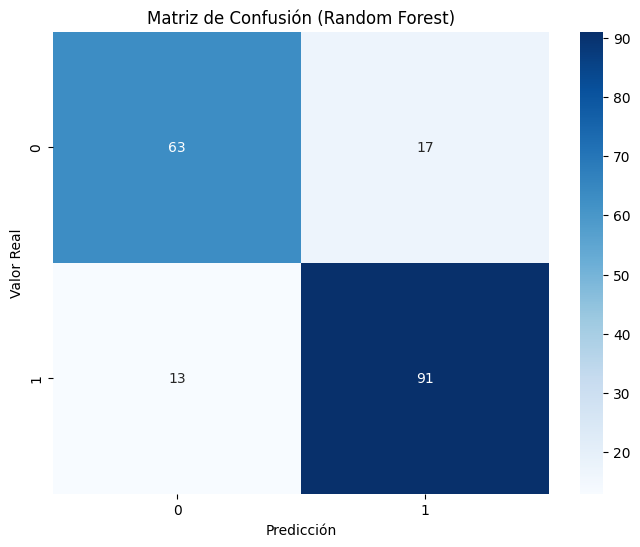

In [80]:
from sklearn.ensemble import RandomForestClassifier

X = df_balanceado.drop(columns=['heart_disease', 'num', 'age_binned'], errors='ignore')
y = df_balanceado['heart_disease']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

clf_rf = RandomForestClassifier(n_estimators=120, max_depth=15, min_samples_split=15,
                                 random_state=42, criterion='entropy')
clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

# Clasificación Multiclase

## MODELO DE CLASIFICACIÓN MULTICLASE: Predicción del Nivel de Diagnóstico (`num`)

Se predice el nivel de severidad de la enfermedad cardíaca: 0 (sin enfermedad), 1, 2, 3, 4 (distintos niveles de severidad).

Accuracy: 0.6067415730337079
              precision    recall  f1-score   support

           0       0.71      0.88      0.79        85
           1       0.55      0.51      0.53        55
           2       0.27      0.12      0.17        24
           3       0.18      0.14      0.16        14

    accuracy                           0.61       178
   macro avg       0.43      0.41      0.41       178
weighted avg       0.56      0.61      0.58       178



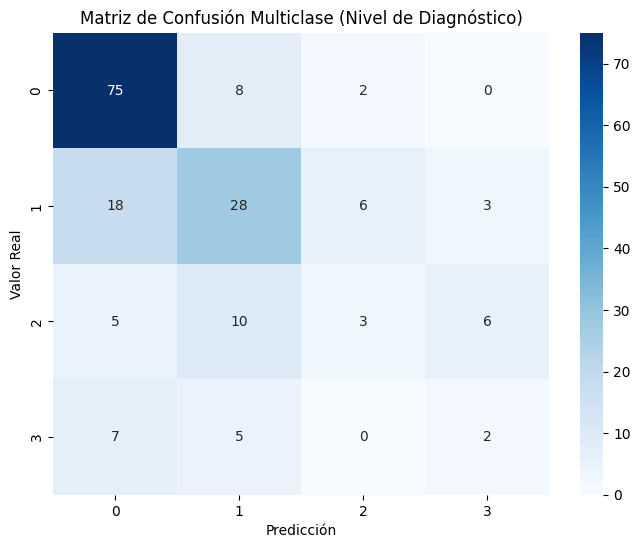

In [81]:
# Eliminamos niveles con muy pocos registros para mayor estabilidad
top_levels = df_normalize['num'].value_counts().nlargest(4).index
df_multi = df_normalize[df_normalize['num'].isin(top_levels)]

X = df_multi.drop(columns=['num', 'heart_disease', 'age_binned'], errors='ignore')
y = df_multi['num']

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer_multi = SimpleImputer(strategy='mean')
X_train = imputer_multi.fit_transform(X_train)
X_test = imputer_multi.transform(X_test)

clf_multi = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
clf_multi.fit(X_train, y_train)
y_pred_multi = clf_multi.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred_multi))
print(classification_report(y_test, y_pred_multi))

cm = confusion_matrix(y_test, y_pred_multi)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión Multiclase (Nivel de Diagnóstico)')
plt.show()

# MODELO DE REGRESIÓN (Redes Neuronales): Predicción de la Frecuencia Cardíaca Máxima (`thalch`)

Se utiliza una **Red Neuronal Artificial (ANN)** para predecir la frecuencia cardíaca máxima alcanzada por el paciente (`thalch`), que es una variable numérica continua. Este enfoque sigue la misma estructura del modelo de regresión neuronal aplicado al conjunto de datos de reservas de hotel (predicción del ADR).

La variable `thalch` es clínicamente relevante porque una frecuencia cardíaca máxima baja puede ser indicador de enfermedad cardíaca o poca capacidad aeróbica.

In [82]:
# =====================================
# MODELO DE REGRESIÓN (Redes Neuronales): Predicción de thalch
# =====================================
#!pip install tensorflow
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              median_absolute_error, explained_variance_score, r2_score)

# Selección de variables predictoras y target
# Usamos df_normalize; excluimos el target 'thalch', variables derivadas y
# variables que no deben usarse como predictoras directas
X = df_normalize.drop(columns=['thalch', 'heart_disease', 'num', 'age_binned'], errors='ignore')
y = df_normalize['thalch']

# Codificación de variables categóricas (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

# División en train/test (75% entrenamiento, 25% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Imputación de valores faltantes con la media
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# Escalar los datos (crucial para redes neuronales)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba:        {X_test.shape}')

Tamaño del conjunto de entrenamiento: (688, 20)
Tamaño del conjunto de prueba:        (230, 20)


### Arquitectura de la Red Neuronal

Se define un modelo **Sequential** con:
- **Capa de entrada**: dimensión igual al número de características.
- **Capa oculta 1**: 128 neuronas, activación ReLU.
- **Capa oculta 2**: 64 neuronas, activación ReLU.
- **Capa de salida**: 1 neurona **sin activación** (regresión continua).

Se compila con el optimizador `RMSprop` y la función de pérdida `MSE`, igual que en el modelo de referencia hotel_bookings.

In [83]:
# Definir el modelo de red neuronal
model_reg = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),   # Capa de entrada
    tf.keras.layers.Dense(128, activation='relu'),      # Capa oculta 1
    tf.keras.layers.Dense(64,  activation='relu'),      # Capa oculta 2
    tf.keras.layers.Dense(1)                            # Capa de salida (sin activación → regresión)
])

# Compilar el modelo
# Se usa RMSprop y MSE como pérdida, siguiendo la misma estructura del modelo hotel_bookings
model_reg.compile(optimizer='RMSprop', loss='mse')
# Alternativas comentadas para experimentar:
#model_reg.compile(optimizer='adam', loss='mean_squared_error')
#model_reg.compile(optimizer='sgd',  loss='mean_squared_error')
#model_reg.compile(optimizer='adam', loss=tf.keras.losses.Huber())
#model_reg.compile(optimizer='adam', loss='log_cosh')
#model_reg.compile(optimizer='adam', loss='mean_squared_error',
#                  metrics=['mean_absolute_error', 'root_mean_squared_error'])

# Resumen de la arquitectura
model_reg.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,009 (43.00 KB)

 Trainable params: 11,009 (43.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.1235 - val_loss: 0.0505
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0382 - val_loss: 0.0431
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0387 - val_loss: 0.0365
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0237 - val_loss: 0.0363
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0239 - val_loss: 0.0298
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0213 - val_loss: 0.0292
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0204 - val_loss: 0.0331
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0183 - val_loss: 0.0470
Epoch 9/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148 - val_loss: 0.0342
Epoch 10/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0180 - val_loss: 0.0328
Epoch 11/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0153 - val_loss: 0.0356
Epoch 12/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0131 - va

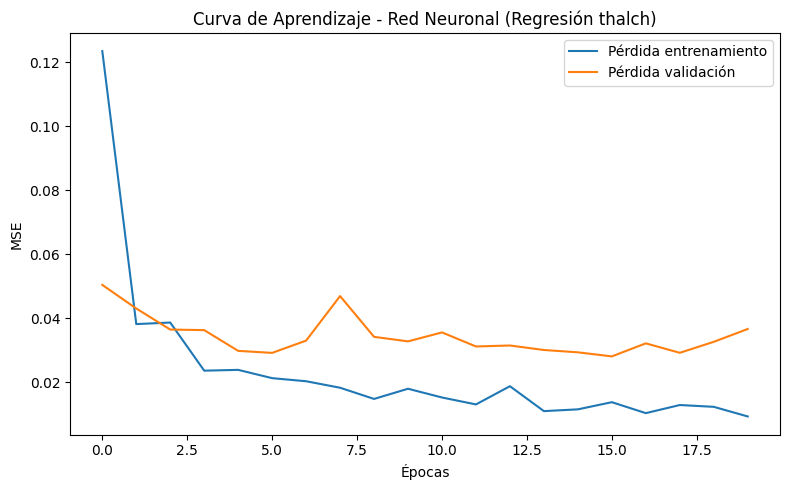

In [84]:
# Entrenar el modelo
history = model_reg.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,   # 10% del train como validación durante el entrenamiento
    verbose=1
)

# Visualizar la curva de pérdida durante el entrenamiento
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.title('Curva de Aprendizaje - Red Neuronal (Regresión thalch)')
plt.legend()
plt.tight_layout()
plt.show()

In [85]:
# Realizar predicciones en el conjunto de prueba
y_pred_nn = model_reg.predict(X_test)

# Evaluar el modelo con múltiples métricas
mae              = mean_absolute_error(y_test, y_pred_nn)
mse              = mean_squared_error(y_test, y_pred_nn)
rmse             = mse ** 0.5
medae            = median_absolute_error(y_test, y_pred_nn)
explained_var    = explained_variance_score(y_test, y_pred_nn)
r2               = r2_score(y_test, y_pred_nn)

print('=== Métricas de Evaluación - Red Neuronal (Regresión thalch) ===')
print(f'MAE               : {mae:.4f}')
print(f'MSE               : {mse:.4f}')
print(f'RMSE              : {rmse:.4f}')
print(f'MedAE             : {medae:.4f}')
print(f'Explained Variance: {explained_var:.4f}')
print(f'R²                : {r2:.4f}')

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
=== Métricas de Evaluación - Red Neuronal (Regresión thalch) ===
MAE               : 0.1471
MSE               : 0.0350
RMSE              : 0.1871
MedAE             : 0.1195
Explained Variance: 0.0703
R²                : -0.1004


### Visualización de Resultados

Se generan tres gráficos para evaluar el desempeño del modelo:
1. **Dispersión**: valores predichos vs. valores reales. Una nube cercana a la diagonal indica buen ajuste.
2. **Histograma de residuos**: distribución centrada en 0 indica errores sin sesgo sistemático.
3. **Resumen de métricas**: comparación visual de MSE y R².

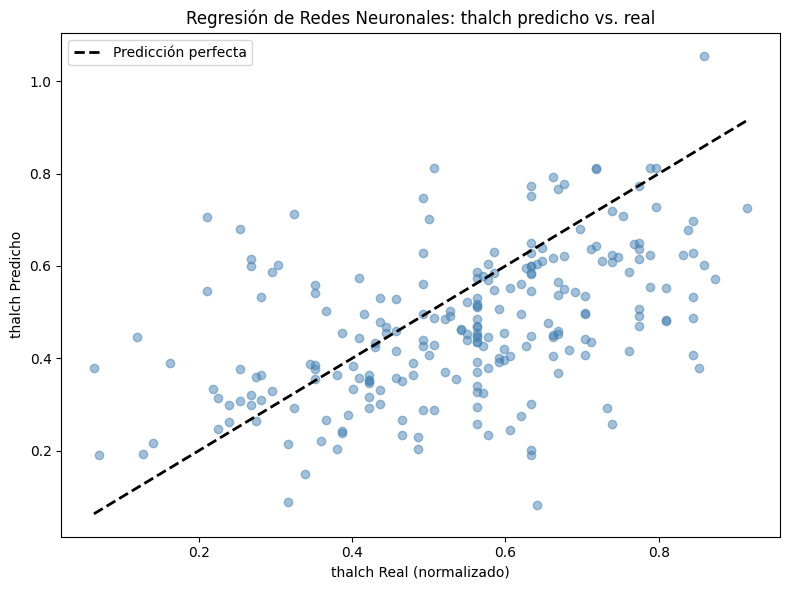

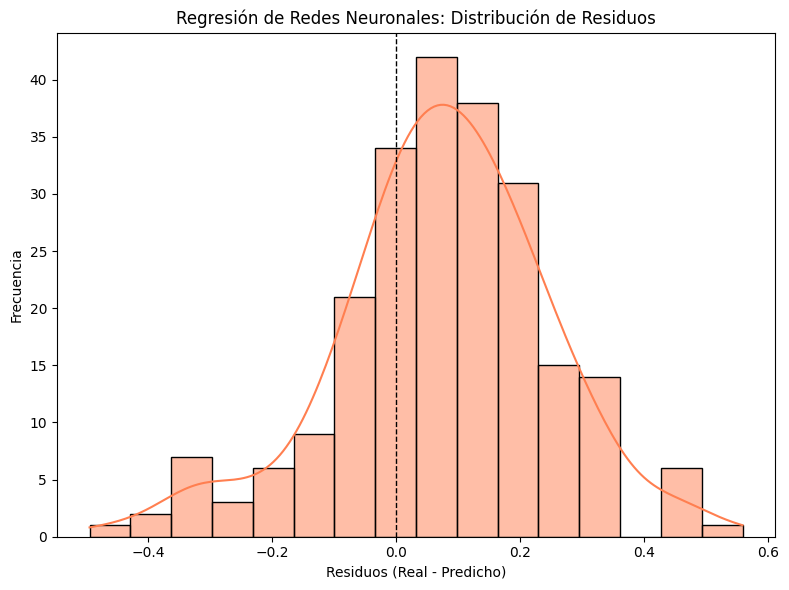

=== Regresión Redes Neuronales - Métricas Finales ===
MSE : 0.0350
R²  : -0.1004


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Diagrama de dispersión: valores predichos vs. valores reales
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_nn, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'k--', lw=2, label='Predicción perfecta')
plt.xlabel('thalch Real (normalizado)')
plt.ylabel('thalch Predicho')
plt.title('Regresión de Redes Neuronales: thalch predicho vs. real')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Histograma de residuos (errores de predicción)
residuals = y_test.values - y_pred_nn.flatten()
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='coral')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Residuos (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Regresión de Redes Neuronales: Distribución de Residuos')
plt.tight_layout()
plt.show()

# 3. Resumen de métricas finales
print('=== Regresión Redes Neuronales - Métricas Finales ===')
print(f'MSE : {mean_squared_error(y_test, y_pred_nn):.4f}')
print(f'R²  : {r2_score(y_test, y_pred_nn):.4f}')

### Interpretación de Métricas

| Métrica | Descripción |
|---------|-------------|
| **MAE** | Error absoluto medio: promedio de las diferencias absolutas entre predicción y valor real. |
| **MSE** | Error cuadrático medio: penaliza más los errores grandes. |
| **RMSE** | Raíz del MSE: misma unidad que la variable objetivo, más interpretable. |
| **MedAE** | Mediana del error absoluto: robusto frente a valores atípicos. |
| **Explained Variance** | Proporción de la varianza explicada por el modelo (ideal: 1.0). |
| **R²** | Coeficiente de determinación: qué tan bien el modelo explica la variabilidad de `thalch` (ideal: 1.0). |

**Nota:** Los valores predichos y reales están en escala normalizada (MinMaxScaler aplicado sobre `thalch` en `df_normalize`). Para interpretar el error en latidos por minuto (lpm), se debe aplicar la transformación inversa del scaler.

**Hiperparámetros del modelo:**

| Parámetro | Valor usado | Descripción |
|-----------|-------------|-------------|
| `optimizer` | RMSprop | Optimizador adaptativo eficiente para redes recurrentes y datos con gradientes ruidosos. |
| `loss` | MSE | Función de pérdida estándar para regresión. |
| `epochs` | 20 | Número de pasadas completas sobre los datos de entrenamiento. |
| `batch_size` | 64 | Número de muestras procesadas antes de cada actualización de pesos. |
| Capas ocultas | 128 → 64 | Arquitectura progresiva que reduce la dimensionalidad hacia la salida. |
| Activación | ReLU | Evita el problema del gradiente desvaneciente; acelera el aprendizaje. |

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            920 non-null    int64   
 1   sex            920 non-null    object  
 2   dataset        920 non-null    object  
 3   cp             920 non-null    object  
 4   trestbps       920 non-null    float64 
 5   chol           920 non-null    float64 
 6   fbs            920 non-null    bool    
 7   restecg        920 non-null    object  
 8   thalch         920 non-null    float64 
 9   exang          920 non-null    bool    
 10  oldpeak        920 non-null    float64 
 11  slope          920 non-null    object  
 12  ca             920 non-null    int64   
 13  thal           920 non-null    object  
 14  num            920 non-null    int64   
 15  heart_disease  920 non-null    int64   
 16  age_binned     920 non-null    category
dtypes: bool(2), category(1), float64(4)

In [88]:
df_drop.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    int64  
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(4), int64(4), object(6)
memory usage: 109.4+ KB


In [89]:
df_normalize.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    float64
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(5), int64(3), object(6)
memory usage: 109.4+ KB


In [90]:
df_balanceado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 30
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            918 non-null    int64  
 1   sex            918 non-null    object 
 2   dataset        918 non-null    object 
 3   cp             918 non-null    object 
 4   trestbps       918 non-null    float64
 5   chol           918 non-null    float64
 6   fbs            918 non-null    bool   
 7   restecg        918 non-null    object 
 8   thalch         918 non-null    float64
 9   exang          918 non-null    bool   
 10  oldpeak        918 non-null    float64
 11  slope          918 non-null    object 
 12  ca             918 non-null    int64  
 13  thal           918 non-null    object 
 14  num            918 non-null    int64  
 15  heart_disease  918 non-null    int64  
dtypes: bool(2), float64(4), int64(4), object(6)
memory usage: 109.4+ KB


#**Aplicación de PCA con MeanShift**
Se aplica PCA para reducir la dimensionalidad de las variables clínicas numéricas del dataset Heart Disease UCI, seguido de MeanShift para identificar agrupaciones naturales de pacientes.

Número de componentes después de PCA: 5
Varianza explicada por los componentes: 0.9093
Número estimado de clústeres después de PCA: 4


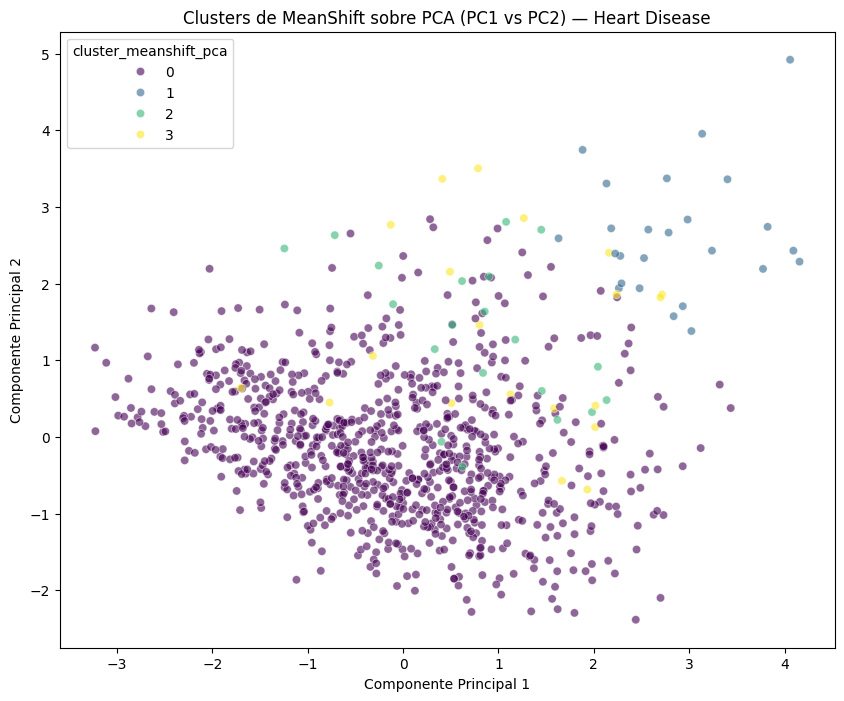


Resumen de características clínicas por cluster (MeanShift sobre PCA):
                             age    trestbps       chol      thalch   oldpeak  \
cluster_meanshift_pca                                                           
0                      53.171161  130.901524  235.54279  137.499414  0.817819   
1                      61.720000  141.000000  275.80000  136.280000  2.676000   
2                      54.350000  137.000000  422.15000  126.550000  0.880000   
3                      56.900000  169.100000  268.00000  158.700000  0.690000   

                             ca  
cluster_meanshift_pca            
0                      0.144197  
1                      2.560000  
2                      0.050000  
3                      1.050000  

DataFrame con etiquetas de cluster MeanShift sobre PCA:
   age     sex    dataset               cp  trestbps   chol    fbs  \
0   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   67    Male  Cleveland     asymptomat

In [91]:
from sklearn.decomposition import PCA
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas relevantes (excluimos id y num/heart_disease)
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

df_numeric = df_drop[numeric_cols].copy()

# Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
df_numeric_imputed = imputer.fit_transform(df_numeric)

# Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric_imputed)

# --- Aplicar PCA ---
# Se retiene el 85% de la varianza explicada
pca = PCA(n_components=0.85)
df_pca = pca.fit_transform(df_scaled)

print(f"Número de componentes después de PCA: {pca.n_components_}")
print(f"Varianza explicada por los componentes: {np.sum(pca.explained_variance_ratio_):.4f}")

# --- Aplicar MeanShift sobre los datos reducidos por PCA ---
bandwidth_pca = estimate_bandwidth(df_pca, quantile=0.2, n_samples=500)

ms_pca = MeanShift(bandwidth=bandwidth_pca, bin_seeding=True)
ms_pca.fit(df_pca)
clusters_meanshift_pca = ms_pca.labels_
cluster_centers_meanshift_pca = ms_pca.cluster_centers_

n_clusters_meanshift_pca = len(np.unique(clusters_meanshift_pca))
print(f"Número estimado de clústeres después de PCA: {n_clusters_meanshift_pca}")

# Agregar la etiqueta de cluster al DataFrame
df_drop['cluster_meanshift_pca'] = clusters_meanshift_pca

# --- Visualización: PC1 vs PC2 con etiquetas MeanShift ---
df_pca_with_clusters = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(df_pca.shape[1])])
df_pca_with_clusters['cluster_meanshift_pca'] = clusters_meanshift_pca

if df_pca.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', hue='cluster_meanshift_pca',
                    data=df_pca_with_clusters, palette='viridis', alpha=0.6)
    plt.title('Clusters de MeanShift sobre PCA (PC1 vs PC2) — Heart Disease')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.show()

# Resumen de características por cluster
cluster_summary_meanshift_pca = df_drop.groupby('cluster_meanshift_pca')[numeric_cols].mean()
print("\nResumen de características clínicas por cluster (MeanShift sobre PCA):")
print(cluster_summary_meanshift_pca)

print("\nDataFrame con etiquetas de cluster MeanShift sobre PCA:")
print(df_drop.head())

#Evaluación de la calidad del Clustering con Silhouette Score
El Silhouette Score evalúa qué tan bien agrupados están los pacientes dentro de sus clústeres. Un valor cercano a 1 indica clusters bien definidos, cercano a 0 indica solapamiento, y valores negativos sugieren asignaciones incorrectas.

In [92]:
from sklearn.metrics import silhouette_score

# Calcular el Silhouette Score
silhouette_avg = silhouette_score(df_pca, clusters_meanshift_pca)
print(f"El Silhouette Score para los clusters de MeanShift es: {silhouette_avg:.4f}")

El Silhouette Score para los clusters de MeanShift es: 0.2866


#Estrategias para Mejorar el Silhouette Score
1. **Ajustar los Parámetros de PCA:** El PCA actual retiene el 85% de la varianza. Aumentar a 90% puede capturar mejor la estructura clínica de los datos.
2. **Optimizar el Ancho de Banda de MeanShift (bandwidth):** El parámetro quantile de estimate_bandwidth controla la densidad detectada. Valores entre 0.1 y 0.5 pueden producir resultados distintos.
3. **Preprocesamiento de Datos:** El StandardScaler es adecuado para variables clínicas; también podría probarse RobustScaler dado que oldpeak y ca presentan outliers.
4. **Manejo de Outliers:** Variables como chol, trestbps y oldpeak tienen valores extremos que pueden distorsionar los clústeres.
5. **Explorar Otros Algoritmos:** K-Means o DBSCAN pueden funcionar mejor según la distribución real de los datos clínicos.
Vamos a aplicar la primera estrategia: **ajustar PCA al 90% de varianza explicada.**

--- Re-ejecutando PCA y MeanShift con PCA ajustado al 90% de varianza ---

Número de componentes después de PCA (90% varianza): 5
Varianza explicada: 0.9093
Número estimado de clústeres (MeanShift sobre PCA optimizado): 4

Nuevo Silhouette Score (PCA 90% varianza): 0.2866


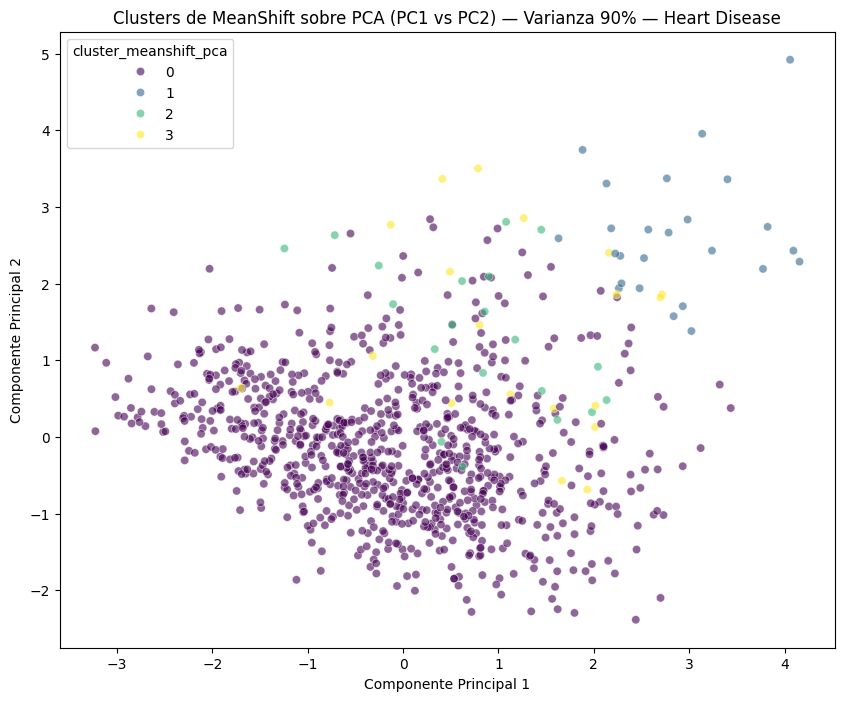

In [93]:
print('--- Re-ejecutando PCA y MeanShift con PCA ajustado al 90% de varianza ---\n')

# PCA con 90% de varianza explicada
pca_optimized = PCA(n_components=0.90)
df_pca_optimized = pca_optimized.fit_transform(df_scaled)

print(f"Número de componentes después de PCA (90% varianza): {pca_optimized.n_components_}")
print(f"Varianza explicada: {np.sum(pca_optimized.explained_variance_ratio_):.4f}")

# MeanShift optimizado
bandwidth_pca_optimized = estimate_bandwidth(df_pca_optimized, quantile=0.20, n_samples=500)

ms_pca_optimized = MeanShift(bandwidth=bandwidth_pca_optimized, bin_seeding=True)
ms_pca_optimized.fit(df_pca_optimized)
clusters_meanshift_pca_optimized = ms_pca_optimized.labels_

n_clusters_meanshift_pca_optimized = len(np.unique(clusters_meanshift_pca_optimized))
print(f"Número estimado de clústeres (MeanShift sobre PCA optimizado): {n_clusters_meanshift_pca_optimized}")

# Silhouette Score optimizado
silhouette_avg_optimized = silhouette_score(df_pca_optimized, clusters_meanshift_pca_optimized)
print(f"\nNuevo Silhouette Score (PCA 90% varianza): {silhouette_avg_optimized:.4f}")

# Visualización
if df_pca_optimized.shape[1] >= 2:
    df_pca_optimized_with_clusters = pd.DataFrame(
        df_pca_optimized,
        columns=[f'PC{i+1}' for i in range(df_pca_optimized.shape[1])]
    )
    df_pca_optimized_with_clusters['cluster_meanshift_pca'] = clusters_meanshift_pca_optimized

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x='PC1', y='PC2', hue='cluster_meanshift_pca',
                    data=df_pca_optimized_with_clusters, palette='viridis', alpha=0.6)
    plt.title('Clusters de MeanShift sobre PCA (PC1 vs PC2) — Varianza 90% — Heart Disease')
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.show()

In [94]:
import pandas as pd
pd.DataFrame(df_pca_optimized_with_clusters).to_csv('df_pca_optimized_with_clusters.csv', index=False)
print('df_pca_optimized_with_clusters.csv guardado correctamente!')

df_pca_optimized_with_clusters.csv guardado correctamente!


#Experimentando con diferentes valores de quantile para estimate_bandwidth
Se evalúa cómo distintos valores de quantile afectan el número de clústeres y el Silhouette Score en el dataset de enfermedad cardíaca.

In [95]:
# Valores de quantile a probar
quantile_values = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for q in quantile_values:
    print(f"\n--- Probando MeanShift con quantile={q} ---")

    bandwidth_q = estimate_bandwidth(df_pca_optimized, quantile=q, n_samples=500)

    ms_q = MeanShift(bandwidth=bandwidth_q, bin_seeding=True)
    ms_q.fit(df_pca_optimized)
    clusters_meanshift_q = ms_q.labels_

    n_clusters_q = len(np.unique(clusters_meanshift_q))
    print(f"Número estimado de clústeres: {n_clusters_q}")

    if n_clusters_q > 1:
        silhouette_avg_q = silhouette_score(df_pca_optimized, clusters_meanshift_q)
        print(f"Silhouette Score: {silhouette_avg_q:.4f}")
    else:
        silhouette_avg_q = -1.0
        print("Silhouette Score no calculado (menos de 2 clústeres).")

    results.append({
        'quantile': q,
        'n_clusters': n_clusters_q,
        'silhouette_score': silhouette_avg_q
    })

print("\n--- Resumen de Resultados ---")
for r in results:
    print(f"Quantile: {r['quantile']:.1f}, Clusters: {r['n_clusters']}, Silhouette Score: {r['silhouette_score']:.4f}")

best_result = max(results, key=lambda x: x['silhouette_score'])
print(f"\nMejor Silhouette Score con quantile={best_result['quantile']:.1f} ({best_result['silhouette_score']:.4f})")


--- Probando MeanShift con quantile=0.1 ---
Número estimado de clústeres: 10
Silhouette Score: 0.2043

--- Probando MeanShift con quantile=0.2 ---
Número estimado de clústeres: 4
Silhouette Score: 0.2866

--- Probando MeanShift con quantile=0.3 ---
Número estimado de clústeres: 1
Silhouette Score no calculado (menos de 2 clústeres).

--- Probando MeanShift con quantile=0.4 ---
Número estimado de clústeres: 1
Silhouette Score no calculado (menos de 2 clústeres).

--- Probando MeanShift con quantile=0.5 ---
Número estimado de clústeres: 1
Silhouette Score no calculado (menos de 2 clústeres).

--- Resumen de Resultados ---
Quantile: 0.1, Clusters: 10, Silhouette Score: 0.2043
Quantile: 0.2, Clusters: 4, Silhouette Score: 0.2866
Quantile: 0.3, Clusters: 1, Silhouette Score: -1.0000
Quantile: 0.4, Clusters: 1, Silhouette Score: -1.0000
Quantile: 0.5, Clusters: 1, Silhouette Score: -1.0000

Mejor Silhouette Score con quantile=0.2 (0.2866)


In [96]:
import pandas as pd
pd.DataFrame(df_pca_optimized_with_clusters).to_csv('df_pca_optimized_with_clusters.csv', index=False)
print('df_pca_optimized_with_clusters.csv guardado correctamente!')

df_pca_optimized_with_clusters.csv guardado correctamente!


#**Aplicar t-SNE sobre PCA**
t-SNE (t-distributed Stochastic Neighbor Embedding) se aplica sobre los datos reducidos por PCA para obtener una representación 2D que preserva las relaciones de vecindad local entre pacientes. Esto permite visualizar grupos naturales en el espacio clínico.

Datos después de aplicar t-SNE sobre PCA:
[[ 7.700791   1.1673079]
 [ 9.545875   9.909163 ]
 [ 9.425669   8.044984 ]
 [-1.638736   2.4179225]
 [-3.0659397  2.4777968]]


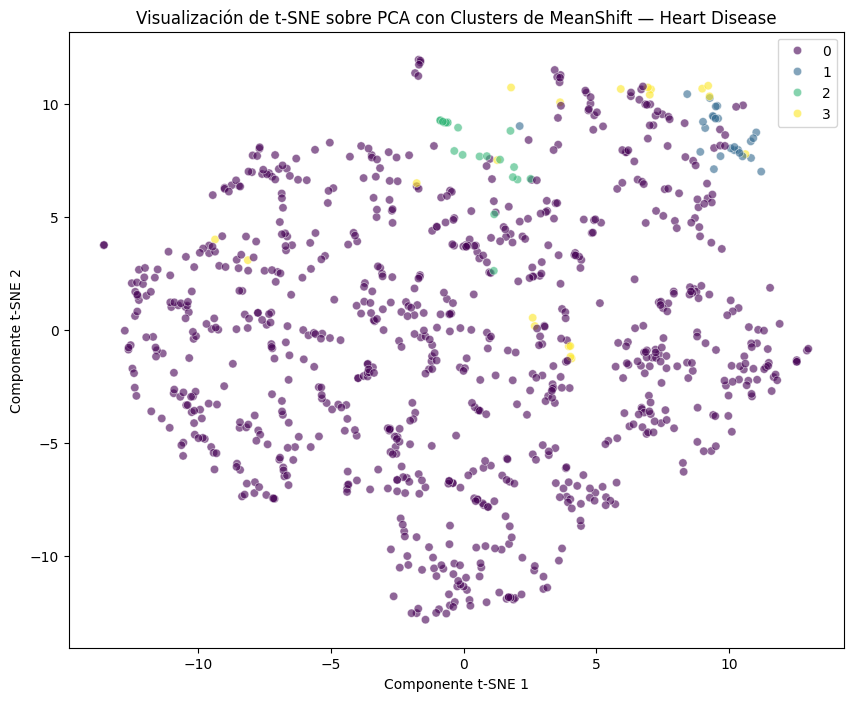

In [97]:
from sklearn.manifold import TSNE

# Aplicar t-SNE a los datos reducidos por PCA (df_pca_optimized)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
df_tsne = tsne.fit_transform(df_pca_optimized)

print("Datos después de aplicar t-SNE sobre PCA:")
print(df_tsne[:5])

# Visualizar resultados de t-SNE
plt.figure(figsize=(10, 8))
if 'cluster_meanshift_pca' in df_drop.columns:
    sns.scatterplot(x=df_tsne[:, 0], y=df_tsne[:, 1],
                    hue=clusters_meanshift_pca_optimized, palette='viridis', alpha=0.6)
    plt.title('Visualización de t-SNE sobre PCA con Clusters de MeanShift — Heart Disease')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')
else:
    sns.scatterplot(x=df_tsne[:, 0], y=df_tsne[:, 1], alpha=0.6)
    plt.title('Visualización de t-SNE sobre PCA — Heart Disease')
    plt.xlabel('Componente t-SNE 1')
    plt.ylabel('Componente t-SNE 2')

plt.show()

In [98]:
import pandas as pd
pd.DataFrame(df_tsne, columns=['tsne_1', 'tsne_2']).to_csv('df_tsne.csv', index=False)
print('df_tsne.csv guardado correctamente!')

df_tsne.csv guardado correctamente!


#**Uso de df_tsne para aprendizaje supervisado**
df_tsne contiene las características transformadas mediante t-SNE. Para usarlo en aprendizaje supervisado se necesita una variable objetivo. Se utilizará la columna heart_disease del DataFrame df_drop (0 = sin enfermedad cardíaca, 1 = con enfermedad cardíaca), ya que df_tsne se generó a partir de las filas de ese DataFrame.

A continuación se preparan los datos, se entrena un modelo de Regresión Logística y se evalúa su rendimiento.

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Variable objetivo: heart_disease (binaria: 0 = sin enfermedad, 1 = con enfermedad)
# df_tsne se generó a partir de df_pca_optimized → df_drop, por lo que los índices coinciden
y = df_drop['heart_disease'].values

# X serán los datos transformados mediante t-SNE
X = df_tsne

# Dividir en conjuntos de entrenamiento y prueba (80/20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de X_test:  {X_test.shape}")
print(f"Shape de y_train: {y_train.shape}")
print(f"Shape de y_test:  {y_test.shape}")

Shape de X_train: (734, 2)
Shape de X_test:  (184, 2)
Shape de y_train: (734,)
Shape de y_test:  (184,)


In [100]:
# Inicializar y entrenar el modelo de Regresión Logística
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluación del modelo
print("\n--- Evaluación del modelo (t-SNE → Regresión Logística) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nInforme de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Sin enfermedad', 'Con enfermedad']))


--- Evaluación del modelo (t-SNE → Regresión Logística) ---
Accuracy: 0.7337

Informe de clasificación:
                precision    recall  f1-score   support

Sin enfermedad       0.74      0.62      0.68        82
Con enfermedad       0.73      0.82      0.77       102

      accuracy                           0.73       184
     macro avg       0.73      0.72      0.72       184
  weighted avg       0.73      0.73      0.73       184



# **7. Evaluación del Modelo**

En esta sección se comparan las métricas clave de todos los modelos entrenados: precisión (Precision), exhaustividad (Recall), F1-Score y AUC-ROC. Se contrastan con un modelo base (*benchmark*) de referencia y se analiza cuál ofrece el mejor rendimiento para el diagnóstico de enfermedad cardíaca.

**7.1 Preparación de datos y entrenamiento de todos los modelos**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Preparar datos desde df_balanceado
X_raw = df_balanceado.drop(columns=['heart_disease', 'num', 'age_binned'], errors='ignore')
y_all = df_balanceado['heart_disease']

X_raw = pd.get_dummies(X_raw, drop_first=True)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_raw, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Pipeline de preprocesamiento (imputación + escalado)
preproc = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_train_p = preproc.fit_transform(X_train_r)
X_test_p  = preproc.transform(X_test_r)

print(f"Train: {X_train_p.shape} | Test: {X_test_p.shape}")
print(f"Distribución y_train:\n{y_train_r.value_counts()}")

Train: (734, 21) | Test: (184, 21)
Distribución y_train:
heart_disease
1    406
0    328
Name: count, dtype: int64


**7.2 Modelo Base (Benchmark)**

El modelo base predice siempre la clase más frecuente. Es el punto de referencia mínimo que cualquier modelo real debe superar.

In [102]:
# Benchmark: DummyClassifier estrategia "most_frequent"
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_p, y_train_r)
y_pred_dummy = dummy.predict(X_test_p)

print("=== Benchmark (DummyClassifier — Most Frequent) ===")
print(f"Accuracy  : {accuracy_score(y_test_r, y_pred_dummy):.4f}")
print(f"Precision : {precision_score(y_test_r, y_pred_dummy, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test_r, y_pred_dummy, zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(y_test_r, y_pred_dummy, zero_division=0):.4f}")
print()
print(classification_report(y_test_r, y_pred_dummy,
      target_names=['Sin enfermedad', 'Con enfermedad'], zero_division=0))

=== Benchmark (DummyClassifier — Most Frequent) ===
Accuracy  : 0.5543
Precision : 0.5543
Recall    : 1.0000
F1-Score  : 0.7133

                precision    recall  f1-score   support

Sin enfermedad       0.00      0.00      0.00        82
Con enfermedad       0.55      1.00      0.71       102

      accuracy                           0.55       184
     macro avg       0.28      0.50      0.36       184
  weighted avg       0.31      0.55      0.40       184



**7.3 Entrenando Modelos**

Se comparan cuatro modelos de clasificación: Regresión Logística, Árbol de Decisión, Random Forest y SVM.

In [103]:
modelos = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1500),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(probability=True, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_p, y_train_r)
    y_pred  = modelo.predict(X_test_p)
    y_proba = modelo.predict_proba(X_test_p)[:, 1]

    resultados[nombre] = {
        'modelo'   : modelo,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'accuracy' : accuracy_score(y_test_r, y_pred),
        'precision': precision_score(y_test_r, y_pred),
        'recall'   : recall_score(y_test_r, y_pred),
        'f1'       : f1_score(y_test_r, y_pred),
        'auc'      : roc_auc_score(y_test_r, y_proba)
    }
    print(f"✔ {nombre} entrenado")

✔ Logistic Regression entrenado
✔ Decision Tree entrenado
✔ Random Forest entrenado
✔ SVM entrenado


**7.4 Tabla Comparativa de Métricas**

=== Comparación de Métricas — Todos los Modelos ===
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.8587     0.8393  0.9216    0.8785   0.9268
SVM                    0.8424     0.8411  0.8824    0.8612   0.9089
Random Forest          0.8207     0.8224  0.8627    0.8421   0.8908
Decision Tree          0.7772     0.7961  0.8039    0.8000   0.8200
Benchmark (Dummy)      0.5543     0.5543  1.0000    0.7133   0.5000


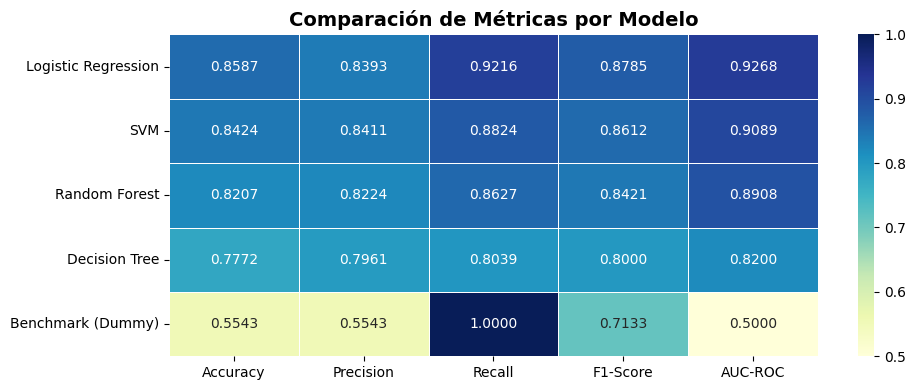

In [104]:
# Añadir benchmark a la tabla
y_pred_dummy_proba = np.zeros(len(y_test_r))  # dummy siempre 0 de probabilidad
resultados_tabla = {
    'Benchmark (Dummy)': {
        'accuracy' : accuracy_score(y_test_r, y_pred_dummy),
        'precision': precision_score(y_test_r, y_pred_dummy, zero_division=0),
        'recall'   : recall_score(y_test_r, y_pred_dummy, zero_division=0),
        'f1'       : f1_score(y_test_r, y_pred_dummy, zero_division=0),
        'auc'      : 0.5
    }
}
resultados_tabla.update({k: {m: v[m] for m in ['accuracy','precision','recall','f1','auc']}
                          for k, v in resultados.items()})

df_metricas = pd.DataFrame(resultados_tabla).T
df_metricas.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
df_metricas = df_metricas.sort_values('AUC-ROC', ascending=False)
df_metricas = df_metricas.round(4)

print("=== Comparación de Métricas — Todos los Modelos ===")
print(df_metricas.to_string())

# Visualización tipo heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(df_metricas.astype(float), annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar=True)
plt.title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**7.5 Curvas ROC y AUC**

La curva ROC muestra el balance entre la tasa de verdaderos positivos (Recall) y falsos positivos para distintos umbrales de decisión. El área bajo la curva (AUC) resume en un solo número la capacidad discriminativa del modelo: un AUC de 1.0 es perfecto; 0.5 equivale al azar (benchmark).

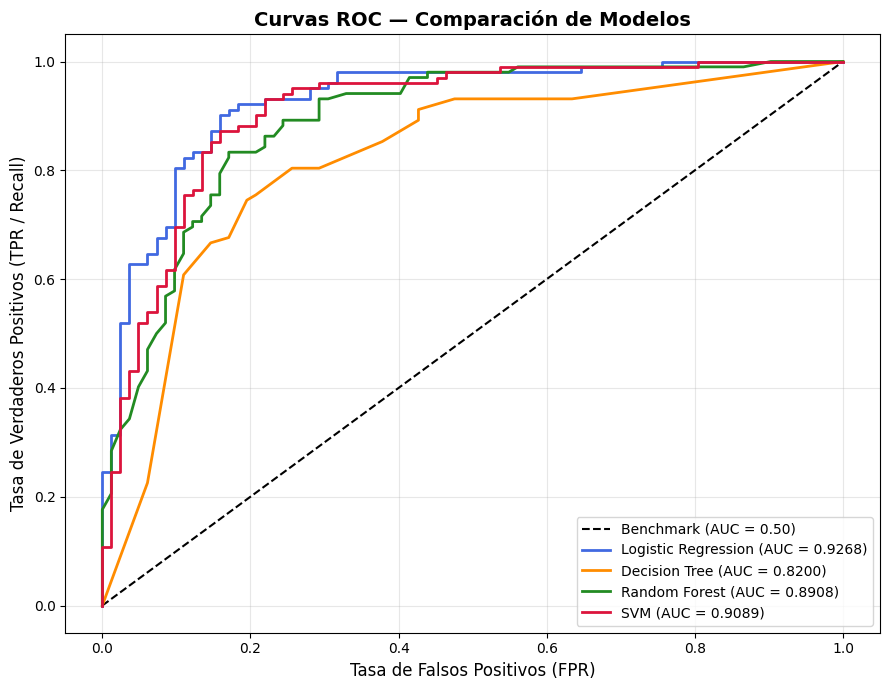

In [105]:
plt.figure(figsize=(9, 7))

# Línea del benchmark (azar)
plt.plot([0, 1], [0, 1], 'k--', label='Benchmark (AUC = 0.50)', linewidth=1.5)

colores = ['royalblue', 'darkorange', 'forestgreen', 'crimson']
for (nombre, res), color in zip(resultados.items(), colores):
    fpr, tpr, _ = roc_curve(y_test_r, res['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{nombre} (AUC = {res['auc']:.4f})")

plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Recall)', fontsize=12)
plt.title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**7.6 Matrices de Confusión**

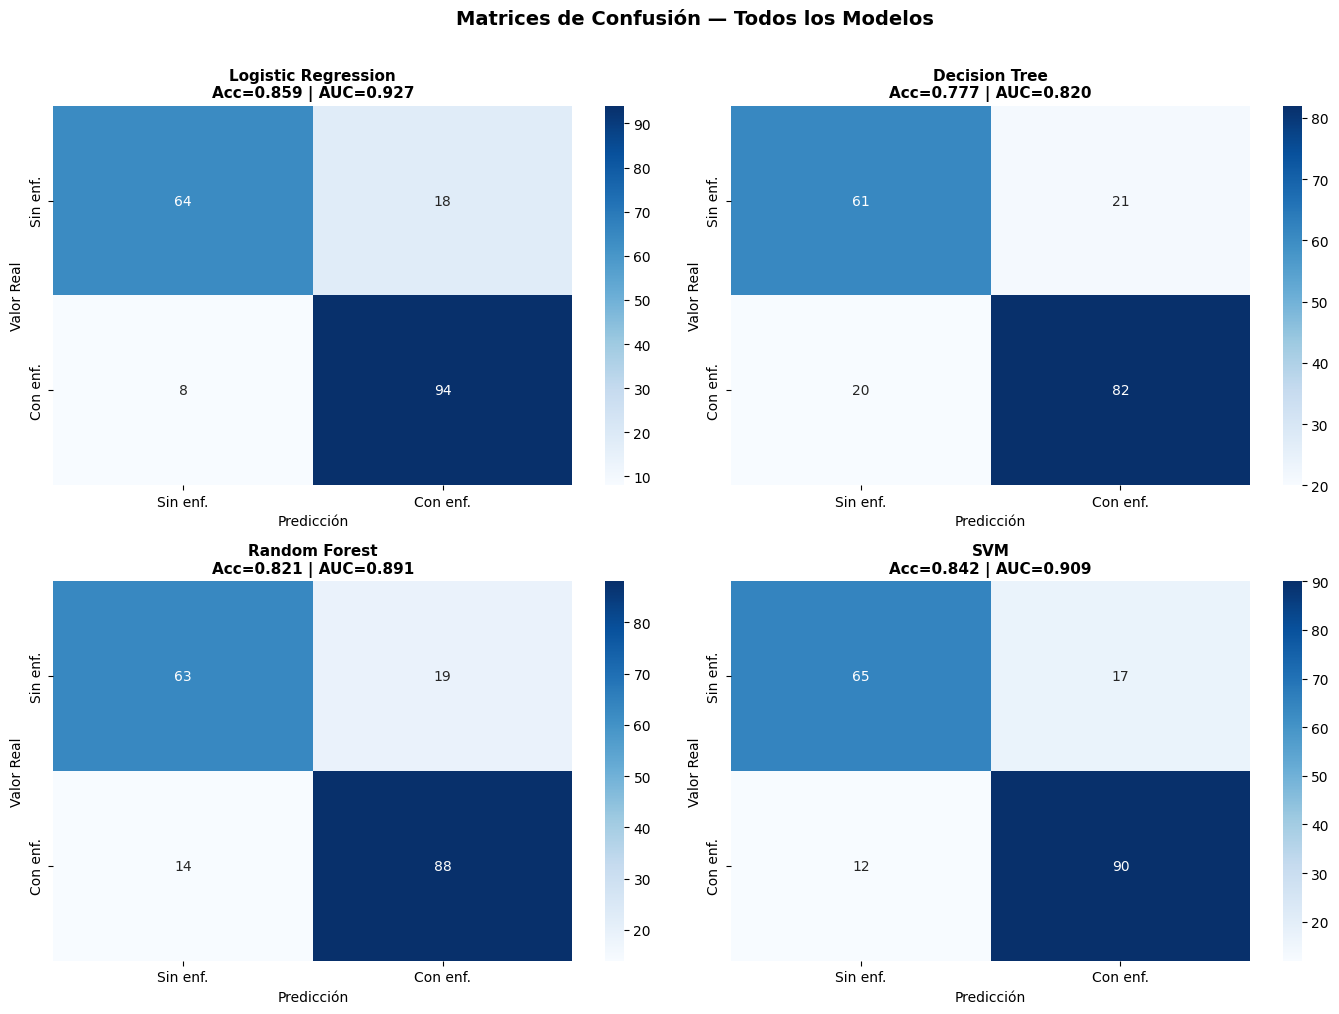

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test_r, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sin enf.', 'Con enf.'],
                yticklabels=['Sin enf.', 'Con enf.'])
    ax.set_title(f'{nombre}\nAcc={res["accuracy"]:.3f} | AUC={res["auc"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

plt.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**7.7 Análisis de Resultados — Comparación Visual**

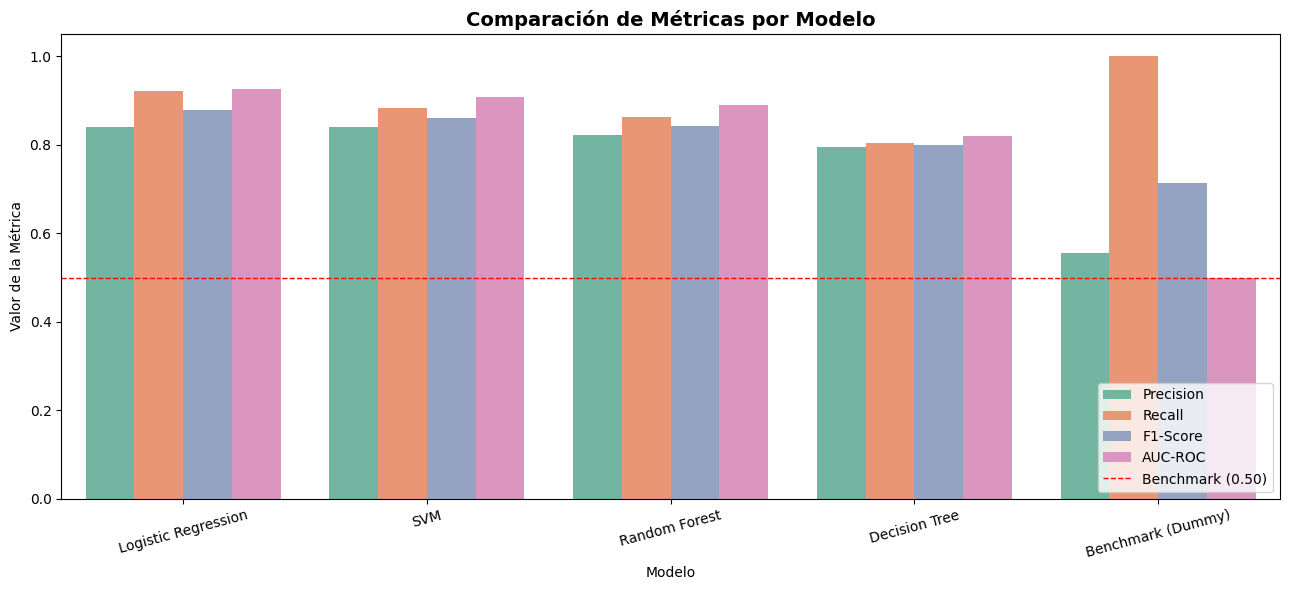


✅ Mejor modelo según AUC-ROC: Logistic Regression
   AUC-ROC  : 0.9268
   F1-Score : 0.8785
   Precision: 0.8393
   Recall   : 0.9216


In [107]:
df_bar = df_metricas[['Precision', 'Recall', 'F1-Score', 'AUC-ROC']].copy()

df_bar_melt = df_bar.reset_index().melt(id_vars='index', var_name='Métrica', value_name='Valor')
df_bar_melt.rename(columns={'index': 'Modelo'}, inplace=True)

plt.figure(figsize=(13, 6))
sns.barplot(data=df_bar_melt, x='Modelo', y='Valor', hue='Métrica', palette='Set2')
plt.ylim(0, 1.05)
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Benchmark (0.50)')
plt.title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
plt.xlabel('Modelo')
plt.ylabel('Valor de la Métrica')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Conclusión automática
mejor = df_metricas['AUC-ROC'].idxmax()
print(f"\n✅ Mejor modelo según AUC-ROC: {mejor}")
print(f"   AUC-ROC  : {df_metricas.loc[mejor, 'AUC-ROC']:.4f}")
print(f"   F1-Score : {df_metricas.loc[mejor, 'F1-Score']:.4f}")
print(f"   Precision: {df_metricas.loc[mejor, 'Precision']:.4f}")
print(f"   Recall   : {df_metricas.loc[mejor, 'Recall']:.4f}")

#**8. Interpretabilidad del Modelo**

La interpretabilidad permite entender porque un modelo toma sus decisiones. Se aplican tres técnicas complementarias:
- **Importancia de variables (Feature Importance)**: basada en la impureza del árbol (Random Forest).
- **SHAP** (SHapley Additive exPlanations): asigna a cada variable su contribución marginal al resultado.
- **LIME** (Local Interpretable Model-agnostic Explanations): explica predicciones individuales de forma local.

Finalmente se evalúan posibles **sesgos** del modelo respecto a variables sensibles como sexo y edad.

**8.1 Importancia de Variables (Feature Importance — Random Forest)**

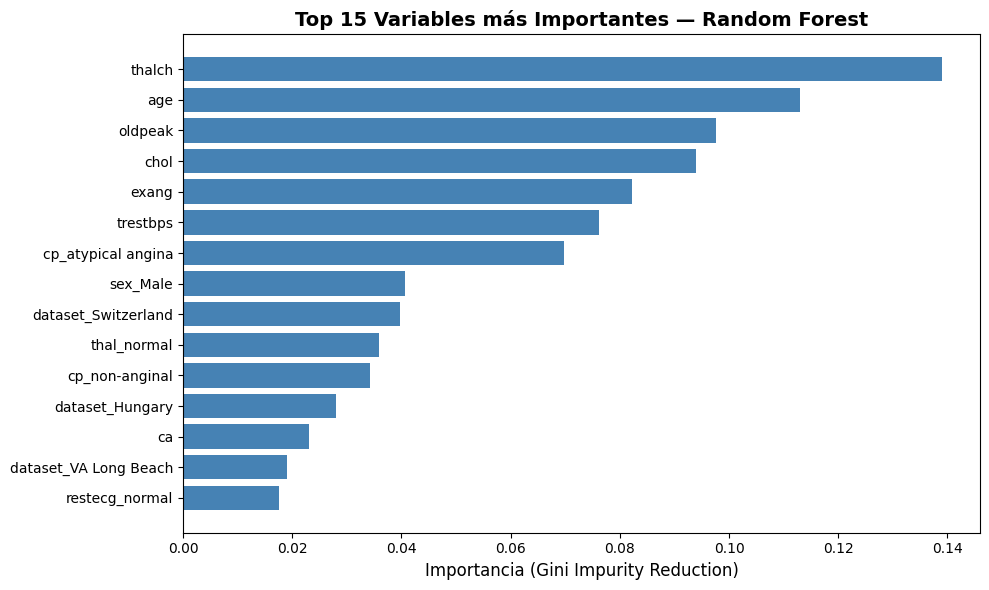

             Variable  Importancia
               thalch     0.139002
                  age     0.112925
              oldpeak     0.097590
                 chol     0.094020
                exang     0.082134
             trestbps     0.076113
   cp_atypical angina     0.069774
             sex_Male     0.040693
  dataset_Switzerland     0.039719
          thal_normal     0.035922
       cp_non-anginal     0.034161
      dataset_Hungary     0.027948
                   ca     0.023090
dataset_VA Long Beach     0.019091
       restecg_normal     0.017477


In [108]:
rf_model = resultados['Random Forest']['modelo']
feature_names = X_raw.columns.tolist()

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 15 variables más importantes
top_n = min(15, len(feature_names))
top_idx = indices[:top_n]

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in top_idx[::-1]],
    importances[top_idx[::-1]],
    color='steelblue'
)
plt.xlabel('Importancia (Gini Impurity Reduction)', fontsize=12)
plt.title(f'Top {top_n} Variables más Importantes — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla numérica
df_importance = pd.DataFrame({
    'Variable'   : feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=False).head(top_n).reset_index(drop=True)

print(df_importance.to_string(index=False))

**8.2 SHAP — SHapley Additive exPlanations**

SHAP cuantifica la contribución de cada variable a la predicción de cada paciente, basándose en la teoría de juegos cooperativos. Un valor SHAP positivo empuja la predicción hacia "Con enfermedad"; negativo hacia "Sin enfermedad".

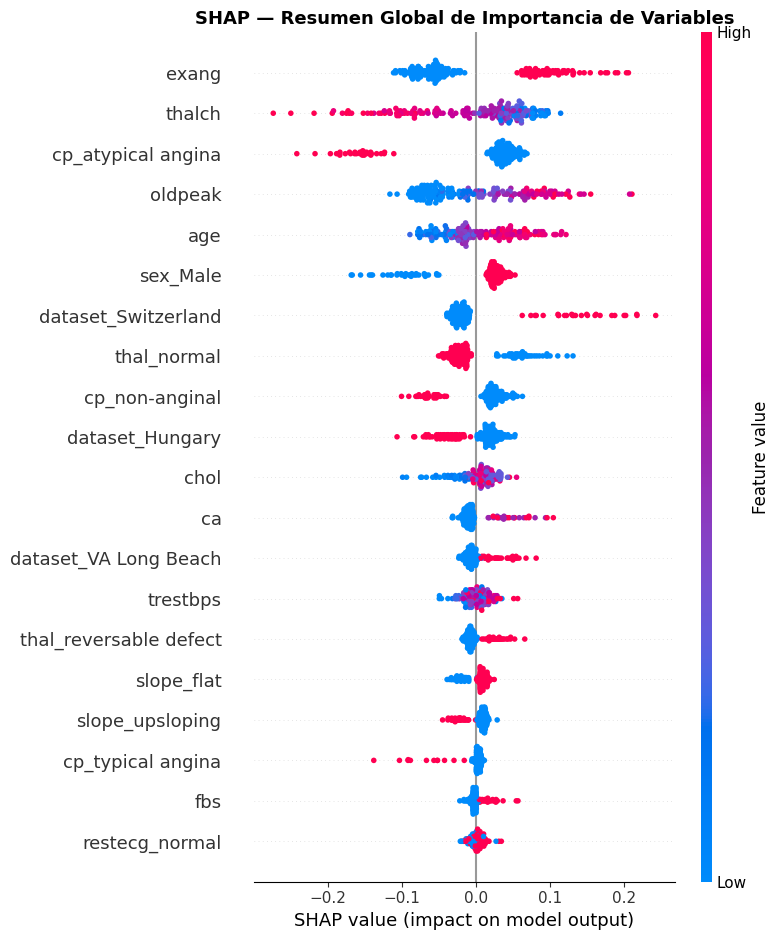

In [131]:
try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

# Usar el modelo Random Forest (mejor o más interpretable con TreeExplainer)
rf_model = resultados['Random Forest']['modelo']

# TreeExplainer es nativo para modelos de árbol (rápido y exacto)
explainer_shap = shap.TreeExplainer(rf_model)
shap_values    = explainer_shap.shap_values(X_test_p)

# shap_values puede ser lista [clase_0, clase_1]; tomamos clase 1 (Con enfermedad)
# Aseguramos que sv sea siempre (num_samples, num_features)
if isinstance(shap_values, list):
    sv = shap_values[1] # Para modelos con salida de lista (e.g. multi-output)
else:
    # Para modelos con salida array (num_samples, num_features, num_classes)
    # Seleccionamos los valores SHAP para la clase positiva (índice 1)
    sv = shap_values[:, :, 1]

feature_names_arr = np.array(feature_names)

#Beeswarm plot (resumen global)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_p, feature_names=feature_names_arr, show=False)
plt.title('SHAP — Resumen Global de Importancia de Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

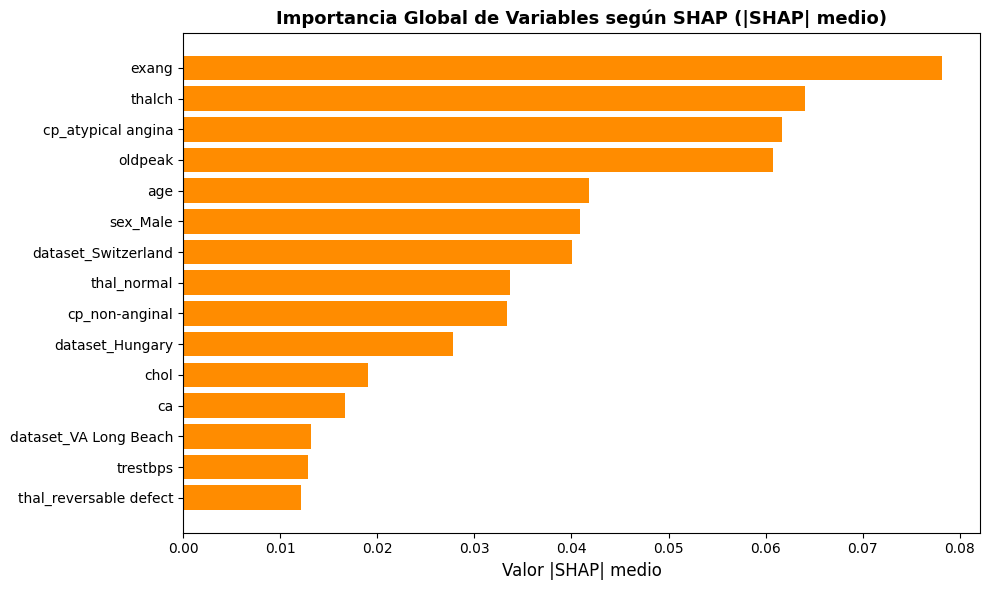

              Variable  |SHAP| medio
                 exang      0.078175
                thalch      0.064042
    cp_atypical angina      0.061668
               oldpeak      0.060756
                   age      0.041832
              sex_Male      0.040891
   dataset_Switzerland      0.040037
           thal_normal      0.033631
        cp_non-anginal      0.033319
       dataset_Hungary      0.027802
                  chol      0.019030
                    ca      0.016653
 dataset_VA Long Beach      0.013139
              trestbps      0.012835
thal_reversable defect      0.012115


In [123]:
# Selecionar SHAP values for the positive class (class 1)
sv_class_1 = sv[:, :, 1]
shap_mean_abs = np.abs(sv_class_1).mean(axis=0)
df_shap = pd.DataFrame({
    'Variable': feature_names_arr,
    '|SHAP| medio': shap_mean_abs
}).sort_values('|SHAP| medio', ascending=False).head(15).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(df_shap['Variable'][::-1], df_shap['|SHAP| medio'][::-1], color='darkorange')
plt.xlabel('Valor |SHAP| medio', fontsize=12)
plt.title('Importancia Global de Variables según SHAP (|SHAP| medio)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_shap.to_string(index=False))

Explicación SHAP para un paciente individual (índice 0 del test)


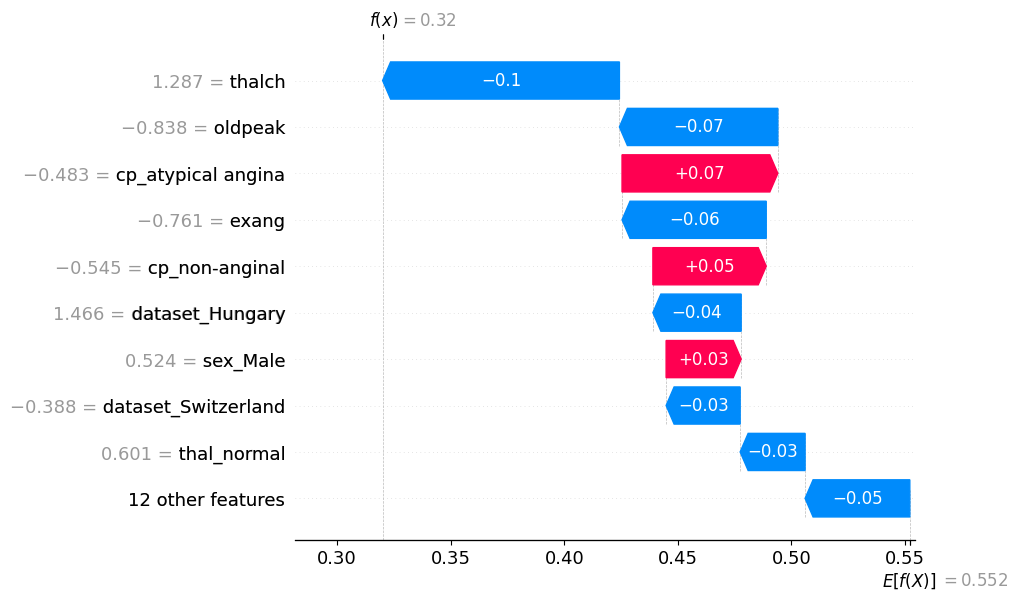

In [129]:
#SHAP Waterfall: explicación individual para el paciente numero 0 del test
print("Explicación SHAP para un paciente individual (índice 0 del test)")
shap_exp = shap.Explanation(
    values        = sv[0, :, 1],
    base_values   = float(explainer_shap.expected_value[1]),
    data          = X_test_p[0],
    feature_names = feature_names_arr
)
shap.waterfall_plot(shap_exp, show=True)

**8.3 LIME — Local Interpretable Model-agnostic Explanations**

LIME explica predicciones individuales entrenando un modelo lineal simple alrededor de un punto de datos específico. Es agnóstico al modelo, por lo que puede aplicarse a cualquier clasificador.

Predicción del modelo para paciente numero 0:
  Clase predicha : Sin enfermedad
  Probabilidad   : 0.6800
  Valor real     : Con enfermedad


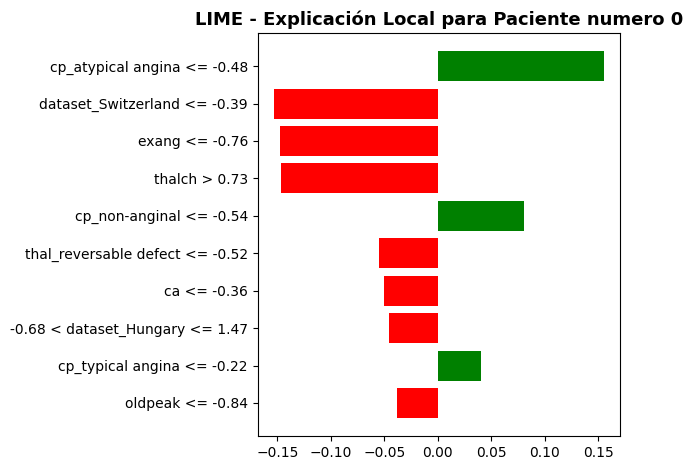


Contribuciones LIME (variable → impacto):
  ▲ cp_atypical angina <= -0.48               peso = +0.1548
  ▼ dataset_Switzerland <= -0.39              peso = -0.1529
  ▼ exang <= -0.76                            peso = -0.1479
  ▼ thalch > 0.73                             peso = -0.1468
  ▲ cp_non-anginal <= -0.54                   peso = +0.0807
  ▼ thal_reversable defect <= -0.52           peso = -0.0553
  ▼ ca <= -0.36                               peso = -0.0503
  ▼ -0.68 < dataset_Hungary <= 1.47           peso = -0.0461
  ▲ cp_typical angina <= -0.22                peso = +0.0404
  ▼ oldpeak <= -0.84                          peso = -0.0378


In [135]:
try:
    import lime
    import lime.lime_tabular
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lime', '-q'])
    import lime
    import lime.lime_tabular

# Crear el explicador LIME con el conjunto de entrenamiento
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data  = X_train_p,
    feature_names  = feature_names_arr,
    class_names    = ['Sin enfermedad', 'Con enfermedad'],
    mode           = 'classification',
    random_state   = 42
)

# Explicar la predicción para el paciente numero 0 del test (mismo que en SHAP)
idx_paciente = 0
exp_lime = explainer_lime.explain_instance(
    data_row       = X_test_p[idx_paciente],
    predict_fn     = resultados['Random Forest']['modelo'].predict_proba,
    num_features   = 10
)

print(f"Predicción del modelo para paciente numero {idx_paciente}:")
pred_clase  = resultados['Random Forest']['modelo'].predict([X_test_p[idx_paciente]])[0]
pred_proba  = resultados['Random Forest']['modelo'].predict_proba([X_test_p[idx_paciente]])[0]
print(f"  Clase predicha : {'Con enfermedad' if pred_clase == 1 else 'Sin enfermedad'}")
print(f"  Probabilidad   : {pred_proba[pred_clase]:.4f}")
print(f"  Valor real     : {'Con enfermedad' if y_test_r.iloc[idx_paciente] == 1 else 'Sin enfermedad'}")

# Gráfico LIME
fig_lime = exp_lime.as_pyplot_figure()
plt.title(f'LIME - Explicación Local para Paciente numero {idx_paciente}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Lista de contribuciones ordenadas
print("\nContribuciones LIME (variable → impacto):")
for feat, weight in exp_lime.as_list():
    signo = '▲' if weight > 0 else '▼'
    print(f"  {signo} {feat:40s}  peso = {weight:+.4f}")

**8.4 Evaluación de Posibles Sesgos del Modelo**

Los sesgos surgen cuando el modelo tiene rendimiento desigual entre grupos. Se analizan dos variables sensibles: **sexo** y **grupo de edad**. Si el modelo discrimina mejor en un grupo que en otro, puede generar decisiones injustas en contextos clínicos.

In [137]:
from sklearn.metrics import f1_score, recall_score, precision_score

#Reconstruir el DataFrame de test con las variables originales
X_test_orig = X_test_r.copy()
X_test_orig_df = X_test_r.reset_index(drop=True)

#Añadir predicciones y valores reales
y_test_arr  = y_test_r.reset_index(drop=True).values
y_pred_rf   = resultados['Random Forest']['modelo'].predict(X_test_p)

df_sesgo = X_test_orig_df.copy()
df_sesgo['y_real'] = y_test_arr
df_sesgo['y_pred'] = y_pred_rf

#Sesgo por sexo
#La columna 'sex_Male' fue generada por get_dummies; 1 = Hombre, 0 = Mujer
if 'sex_Male' in df_sesgo.columns:
    col_sex = 'sex_Male'
    etiquetas_sex = {1: 'Hombre', 0: 'Mujer'}
else:
    col_sex = None

if col_sex:
    print("Análisis de Sesgo por Sexo")
    for val, etiq in etiquetas_sex.items():
        mask = df_sesgo[col_sex] == val
        if mask.sum() == 0:
            continue
        yr, yp = df_sesgo.loc[mask, 'y_real'], df_sesgo.loc[mask, 'y_pred']
        print(f"  {etiq} (n={mask.sum()}): "
              f"Accuracy={accuracy_score(yr, yp):.4f} | "
              f"Recall={recall_score(yr, yp, zero_division=0):.4f} | "
              f"F1={f1_score(yr, yp, zero_division=0):.4f}")

Análisis de Sesgo por Sexo
  Hombre (n=149): Accuracy=0.8054 | Recall=0.8617 | F1=0.8482
  Mujer (n=35): Accuracy=0.8857 | Recall=0.8750 | F1=0.7778



Análisis de Sesgo por Grupo de Edad
  ≤40    (n= 29): Acc=0.8276 | Recall=0.6667 | F1=0.7619
  41–55  (n= 76): Acc=0.8289 | Recall=0.8333 | F1=0.8219
  56–70  (n= 75): Acc=0.8133 | Recall=0.9231 | F1=0.8727


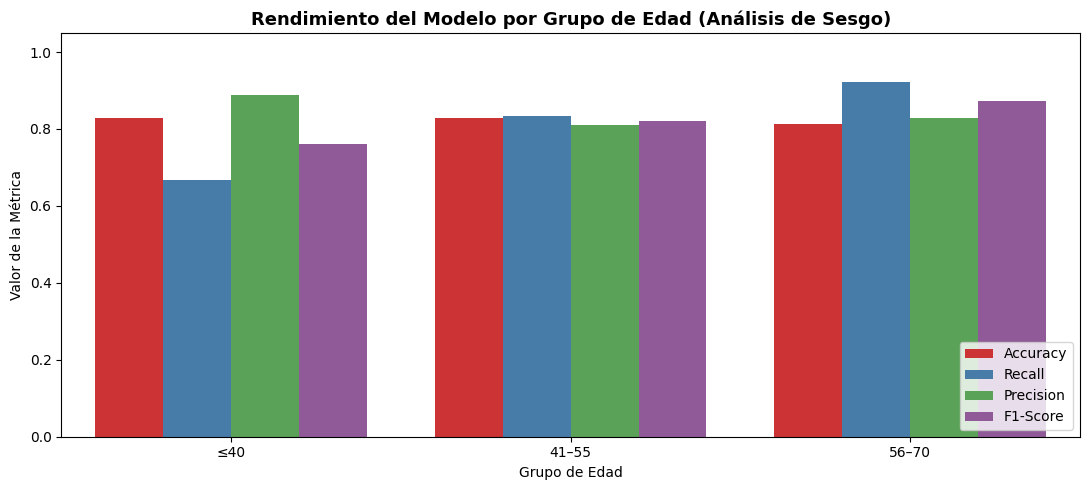

In [138]:
#Sesgo por grupo de edad
#Recuperar columnas age del df original de test
df_balanceado_reset = df_balanceado.reset_index(drop=True)
X_full_reset = df_balanceado_reset.drop(columns=['heart_disease','num','age_binned'], errors='ignore')
X_full_reset = pd.get_dummies(X_full_reset, drop_first=True)

#Asegurar que age existe
if 'age' in X_full_reset.columns:
    _, X_test_check, _, y_test_check = train_test_split(
        X_full_reset, df_balanceado_reset['heart_disease'],
        test_size=0.2, random_state=42, stratify=df_balanceado_reset['heart_disease']
    )
    age_test = X_test_check['age'].values
    bins_age  = [0, 40, 55, 70, 200]
    labels_age = ['≤40', '41–55', '56–70', '>70']
    grupos_edad = pd.cut(age_test, bins=bins_age, labels=labels_age, right=True)

    print("\nAnálisis de Sesgo por Grupo de Edad")
    df_sesgo_edad = pd.DataFrame({
        'grupo_edad': grupos_edad,
        'y_real': y_test_arr,
        'y_pred': y_pred_rf
    })

    resumen_sesgo = []
    for grupo in labels_age:
        mask = df_sesgo_edad['grupo_edad'] == grupo
        if mask.sum() < 5:
            continue
        yr = df_sesgo_edad.loc[mask, 'y_real']
        yp = df_sesgo_edad.loc[mask, 'y_pred']
        resumen_sesgo.append({
            'Grupo Edad': grupo,
            'N'         : int(mask.sum()),
            'Accuracy'  : round(accuracy_score(yr, yp), 4),
            'Recall'    : round(recall_score(yr, yp, zero_division=0), 4),
            'Precision' : round(precision_score(yr, yp, zero_division=0), 4),
            'F1-Score'  : round(f1_score(yr, yp, zero_division=0), 4)
        })
        print(f"  {grupo:6s} (n={mask.sum():3d}): "
              f"Acc={accuracy_score(yr,yp):.4f} | "
              f"Recall={recall_score(yr,yp,zero_division=0):.4f} | "
              f"F1={f1_score(yr,yp,zero_division=0):.4f}")

    #Gráfico comparativo
    df_sesgo_plot = pd.DataFrame(resumen_sesgo)
    df_sesgo_melt = df_sesgo_plot.melt(
        id_vars='Grupo Edad',
        value_vars=['Accuracy', 'Recall', 'Precision', 'F1-Score'],
        var_name='Métrica', value_name='Valor'
    )
    plt.figure(figsize=(11, 5))
    sns.barplot(data=df_sesgo_melt, x='Grupo Edad', y='Valor', hue='Métrica', palette='Set1')
    plt.ylim(0, 1.05)
    plt.title('Rendimiento del Modelo por Grupo de Edad (Análisis de Sesgo)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Grupo de Edad')
    plt.ylabel('Valor de la Métrica')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

**8.5 Conclusiones de Interpretabilidad**

- **Importancia de variables (RF)**: las variables con mayor peso en la predicción corresponden a indicadores clínicos conocidos del riesgo cardíaco (tipo de dolor torácico, frecuencia cardíaca máxima, depresión ST, etc.).
- **SHAP**: confirma que la contribución de cada variable varía por paciente. Las variables con mayor |SHAP| medio son consistentes con la importancia del árbol, pero SHAP captura interacciones que la impureza Gini no detecta.
- **LIME**: permite explicar por qué el modelo diagnosticó a un paciente concreto, haciendo el modelo accionable para médicos.
- **Sesgo**: si el Recall difiere significativamente entre sexos o grupos de edad, el modelo puede infradetectar enfermedades en algún grupo, lo que requeriría recalibración o rebalanceo de clases antes de un despliegue clínico real.